<a href="https://colab.research.google.com/github/BenRyan-8/APA_CA/blob/main/Copy_of_BERPrediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Predicting BER using ML Techniques

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
!pip install openpyxl

#### Data Loading

In [ ]:
import pandas as pd
import openpyxl

df = pd.read_excel('/content/drive/MyDrive/FourthYear/APA/BERPublicsearch.xlsx', nrows=100000)


In [ ]:
#Keep copy to save having to load in data again
df_copy=df.copy()
#df=df_copy

In [ ]:
df.columns.tolist()

['CountyName',
 'DwellingTypeDescr',
 'Year_of_Construction',
 'TypeofRating',
 'EnergyRating',
 'BerRating',
 'GroundFloorArea(sq m)',
 'UValueWall',
 'UValueRoof',
 'UValueFloor',
 'UValueWindow',
 'UvalueDoor',
 'WallArea',
 'RoofArea',
 'FloorArea',
 'WindowArea',
 'DoorArea',
 'NoStoreys',
 'CO2Rating',
 'MainSpaceHeatingFuel',
 'MainWaterHeatingFuel',
 'HSMainSystemEfficiency',
 'MultiDwellingMPRN',
 'TGDLEdition',
 'MPCDERValue',
 'HSEffAdjFactor',
 'HSSupplHeatFraction',
 'HSSupplSystemEff',
 'WHMainSystemEff',
 'WHEffAdjFactor',
 'SupplSHFuel',
 'SupplWHFuel',
 'SHRenewableResources',
 'WHRenewableResources',
 'NoOfChimneys',
 'NoOfOpenFlues',
 'NoOfFansAndVents',
 'NoOfFluelessGasFires',
 'DraftLobby',
 'VentilationMethod',
 'FanPowerManuDeclaredValue',
 'HeatExchangerEff',
 'StructureType',
 'SuspendedWoodenFloor',
 'PercentageDraughtStripped',
 'NoOfSidesSheltered',
 'PermeabilityTest',
 'PermeabilityTestResult',
 'TempAdjustment',
 'HeatSystemControlCat',
 'HeatSystemRespo

#Data Cleaning

#### Column Removal (Leakage, DEAP-derived, Redundant Fields)

In [ ]:
cols_to_remove = [

    # DIRECT BER COMPONENTS
    "BerRating",
    "CO2Rating",

    # DELIVERED ENERGY FIELDS
    "DeliveredLightingEnergy",
    "DeliveredEnergyPumpsFans",
    "DeliveredEnergyMainWater",
    "DeliveredEnergyMainSpace",
    "DeliveredEnergySecondarySpace",
    "DeliveredEnergySupplementaryWater",
    "TotalDeliveredEnergy",

    # PRIMARY ENERGY FIELDS
    "PrimaryEnergyLighting",
    "PrimaryEnergyPumpsFans",
    "PrimaryEnergyMainWater",
    "PrimaryEnergyMainSpace",
    "PrimaryEnergySecondarySpace",
    "PrimaryEnergySupplementaryWater",

    # CO2 EMISSIONS FIELDS
    "CO2Lighting",
    "CO2PumpsFans",
    "CO2MainWater",
    "CO2MainSpace",
    "CO2SecondarySpace",
    "CO2SupplementaryWater",

    # DEAP COMPLIANCE & PERFORMANCE COEFFICIENTS
    "CPC",
    "EPC",
    "RER",
    "RenewEPnren",
    "RenewEPren",

    # HIGHLY DERIVED / SEMI-LEAKAGE FIELDS
    "LivingAreaPercent",

    # RENEWABLE ENERGY SUBCOMPONENT FIELDS
    # Renewable Energy 1
    "FirstEnergyTypeId",
    "FirstEnergyType_Description",
    "FirstEnerProdComment",
    "FirstEnerProdDelivered",
    "FirstPartLTotalContribution",
    "FirstEnerProdConvFactor",
    "FirstEnerProdCO2EmissionFactor",
    "FirstEnerConsumedComment",
    "FirstEnerConsumedDelivered",
    "FirstEnerConsumedConvFactor",
    "FirstEnerConsumedCO2EmissionFactor",

    # Renewable Energy 2
    "SecondEnergyTypeId",
    "SecondEnergyType_Description",
    "SecondEnerProdComment",
    "SecondEnerProdDelivered",
    "SecondPartLTotalContribution",
    "SecondEnerProdConvFactor",
    "SecondEnerProdCO2EmissionFactor",
    "SecondEnerConsumedComment",
    "SecondEnerConsumedDelivered",
    "SecondEnerConsumedConvFactor",
    "SecondEnerConsumedCO2EmissionFactor",

    # Renewable Energy 3
    "ThirdEnergyTypeId",
    "ThirdEnergyType_Description",
    "ThirdEnerProdComment",
    "ThirdEnerProdDelivered",
    "ThirdPartLTotalContribution",
    "ThirdEnerProdConvFactor",
    "ThirdEnerProdCO2EmissionFactor",
    "ThirdEnerConsumedComment",
    "ThirdEnerConsumedDelivered",
    "ThirdEnerConsumedConvFactor",
    "ThirdEnerConsumedCO2EmissionFactor",

    # GROUP HEATING SCHEME FIELDS
    "ChargingBasisHeatConsumed",
    "gsdHSSupplHeatFraction",
    "gsdHSSupplSystemEff",
    "DistLossFactor",
    "CHPUnitHeatFraction",
    "CHPSystemType",
    "CHPElecEff",
    "CHPHeatEff",
    "CHPFuelType",
    "SupplHSFuelTypeID",
    "gsdSHRenewableResources",
    "gsdWHRenewableResources",
    "SolarHeatFraction",
    "TotalPrimaryEnergyFact",
    "TotalCO2Emissions",

    # WALL-BY-WALL STRUCTURE FIELDS

    # First wall (GA → GG)
    "FirstWallType_Description",
    "FirstWallDescription",
    "FirstWallArea",
    "FirstWallUValue",
    "FirstWallIsSemiExposed",
    "FirstWallAgeBandId",
    "FirstWallTypeId",

    # Second wall (GH → GN)
    "SecondWallType_Description",
    "SecondWallDescription",
    "SecondWallArea",
    "SecondWallUValue",
    "SecondWallIsSemiExposed",
    "SecondWallAgeBandId",
    "SecondWallTypeId",

    # Third wall (GO → GU)
    "ThirdWallType_Description",
    "ThirdWallDescription",
    "ThirdWallArea",
    "ThirdWallUValue",
    "ThirdWallIsSemiExposed",
    "ThirdWallAgeBandId",
    "ThirdWallTypeId",

    # MISCELLANEOUS STRUCTURAL FIELDS
    "GroundFloorUValue",
    "LowEnergyLightingPercent",
    "PurposeOfRating",
    "DateOfAssessment",
    "VolumeOfPreHeatStore",

    # SPATIAL METADATA
    "SA_Code",
    "prob_smarea_error_0corr",
    "prob_smarea_error_100corr",

    # NEW — DEAP-DERIVED HEATING / CONTROL VARIABLES (MUST REMOVE)
    "HSSupplSystemEff",
    "WHMainSystemEff",
    "WHEffAdjFactor",
    "TempAdjustment",
    "HeatSystemControlCat",
    "HeatSystemResponseCat",
    "TempFactorUnadj",
    "TempFactorMultiplier",
    "PrimaryCircuitLoss",
    "CombiBoilerAddLoss",
    "MPCDERValue"
]


In [ ]:
df.drop(columns=cols_to_remove, inplace=True)

#### Missing Data Analysis & Visualisation

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Calculate the percentage of missing values for each column
missing_data = df.isnull().sum() / len(df) * 100

# Filter out columns with no missing data if desired, or sort for better visualization
missing_data = missing_data[missing_data > 0].sort_values(ascending=False)


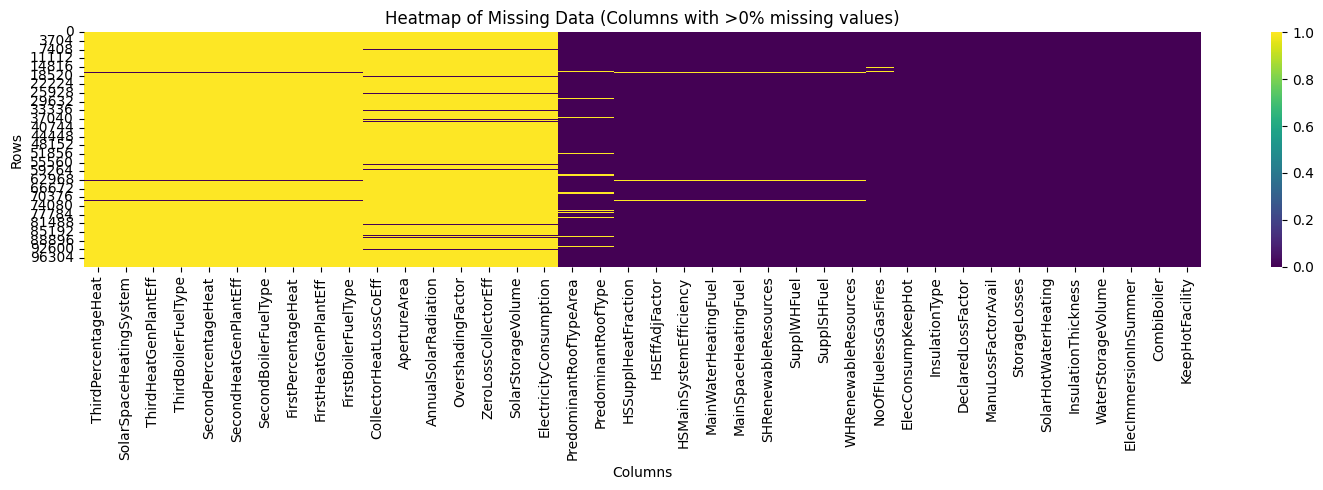

In [ ]:
# A more detailed heatmap of only columns with missing values (if `missing_data` Series is not empty)
if not missing_data.empty:
    plt.figure(figsize=(15, 5))
    sns.heatmap(
        df[missing_data.index].isnull(),
        cbar=True,
        cmap='viridis'
    )
    plt.title('Heatmap of Missing Data (Columns with >0% missing values)')
    plt.xlabel('Columns')
    plt.ylabel('Rows')
    plt.xticks(rotation=90)
    plt.tight_layout()
    plt.show()
else:
    print("No columns with missing values to display a detailed heatmap.")


In [ ]:
threshold = 0.9

# Identify columns with > 90% missing
cols_over_90_missing = df.columns[df.isna().mean() > threshold].tolist()

print("Columns with >90% missing:", cols_over_90_missing)


Columns with >90% missing: ['ApertureArea', 'ZeroLossCollectorEff', 'CollectorHeatLossCoEff', 'AnnualSolarRadiation', 'OvershadingFactor', 'SolarStorageVolume', 'ElectricityConsumption', 'FirstBoilerFuelType', 'FirstHeatGenPlantEff', 'FirstPercentageHeat', 'SecondBoilerFuelType', 'SecondHeatGenPlantEff', 'SecondPercentageHeat', 'ThirdBoilerFuelType', 'ThirdHeatGenPlantEff', 'ThirdPercentageHeat', 'SolarSpaceHeatingSystem']


In [ ]:
# Filter the missing_data Series to include only columns identified as having >90% missing
missing_data_over_90 = missing_data[missing_data.index.isin(cols_over_90_missing)]

print("Columns with over 90% missing data and their percentages:")
display(missing_data_over_90.sort_values(ascending=False))


Columns with over 90% missing data and their percentages:


,0
ThirdPercentageHeat,98.673
SolarSpaceHeatingSystem,98.673
ThirdHeatGenPlantEff,98.673
ThirdBoilerFuelType,98.673
SecondPercentageHeat,98.673
SecondHeatGenPlantEff,98.673
SecondBoilerFuelType,98.673
FirstPercentageHeat,98.673
FirstHeatGenPlantEff,98.673
FirstBoilerFuelType,98.673


In [ ]:
# Drop them
df.drop(columns=cols_over_90_missing, inplace=True)

dropping columns that only contain one value as it doesn't provide any value to the model

In [ ]:
cols_to_drop_single_value = []
for col in df.columns:
    if df[col].nunique() == 1:
        cols_to_drop_single_value.append(col)

if cols_to_drop_single_value:
    print(f"Dropping {len(cols_to_drop_single_value)} columns with only one unique value: {cols_to_drop_single_value}")
    df.drop(columns=cols_to_drop_single_value, inplace=True)
    print("Columns dropped successfully.")
else:
    print("No columns found with only one unique value.")

print(f"New DataFrame shape: {df.shape}")

No columns found with only one unique value.
New DataFrame shape: (100000, 79)


#### Target Cleaning & String Normalisation

Checking for how rare the A ratings are and then grouping them into just A

In [ ]:
df["EnergyRating"].value_counts().sort_index()


,count
EnergyRating,
A1,1
A2,213
A3,1794
B1,1307
B2,2244
B3,6288
C1,10671
C2,12950
C3,13023


In [ ]:
df["EnergyRating"] = df["EnergyRating"].replace({"A1":"A", "A2":"A", "A3":"A"})

# Remove leading/trailing whitespace and uppercase just in case
df["EnergyRating"] = df["EnergyRating"].astype(str).str.strip().str.upper()

# Remove leading/trailing whitespace from all object (string) columns in the DataFrame
for col in df.select_dtypes(include=['object']).columns:
    df[col] = df[col].astype(str).str.strip()

In [ ]:
initial_rows = df.shape[0]
df.drop_duplicates(inplace=True)
final_rows = df.shape[0]

print(f"Number of duplicate rows dropped: {initial_rows - final_rows}")

Number of duplicate rows dropped: 2579


#Imputation

In [ ]:
import numpy as np

# Identify column types automatically
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = df.select_dtypes(include=["object", "category"]).columns.tolist()

In [ ]:
numeric_cols, categorical_cols

(['Year_of_Construction',
  'GroundFloorArea(sq m)',
  'UValueWall',
  'UValueRoof',
  'UValueFloor',
  'UValueWindow',
  'UvalueDoor',
  'WallArea',
  'RoofArea',
  'FloorArea',
  'WindowArea',
  'DoorArea',
  'NoStoreys',
  'HSMainSystemEfficiency',
  'TGDLEdition',
  'HSEffAdjFactor',
  'HSSupplHeatFraction',
  'SupplSHFuel',
  'SupplWHFuel',
  'SHRenewableResources',
  'WHRenewableResources',
  'NoOfChimneys',
  'NoOfOpenFlues',
  'NoOfFansAndVents',
  'NoOfFluelessGasFires',
  'FanPowerManuDeclaredValue',
  'HeatExchangerEff',
  'PercentageDraughtStripped',
  'NoOfSidesSheltered',
  'PermeabilityTestResult',
  'NoCentralHeatingPumps',
  'NoOilBoilerHeatingPumps',
  'NoGasBoilerHeatingPumps',
  'DistributionLosses',
  'WaterStorageVolume',
  'DeclaredLossFactor',
  'InsulationThickness',
  'ElecConsumpKeepHot',
  'GroundFloorArea',
  'GroundFloorHeight',
  'FirstFloorArea',
  'FirstFloorHeight',
  'SecondFloorArea',
  'SecondFloorHeight',
  'ThirdFloorArea',
  'ThirdFloorHeight',
 

##Numerical Imputation

In [ ]:

numerical_but_categorical = [
    "TGDLEdition",
    "ThermalMassCategory",
    "PredominantRoofType",
    'SupplSHFuel',
    'SupplWHFuel',
    'SHRenewableResources',
    'WHRenewableResources',
    'HESSchemeUpgrade'
]

# Move overrides into categorical
for col in numerical_but_categorical:
    if col in numeric_cols:
        numeric_cols.remove(col)
    if col not in categorical_cols:
        categorical_cols.append(col)

df[numerical_but_categorical] = df[numerical_but_categorical].astype("str")


In [ ]:
# Filter for numerical columns
numeric_df = df.select_dtypes(include=['number'])

zero_counts = {}

for col in numeric_df.columns:
    count = (numeric_df[col] == 0).sum()
    if count > 0:
        zero_counts[col] = count

if zero_counts:
    print("Number of 0's contained in each numerical column:")
    for col, count in zero_counts.items():
        print(f"Column '{col}': {count} zeros")
else:
    print("No numerical columns contain the value 0.")

Number of 0's contained in each numerical column:
Column 'UValueWall': 14 zeros
Column 'UValueRoof': 8892 zeros
Column 'UValueFloor': 10035 zeros
Column 'UValueWindow': 21 zeros
Column 'UvalueDoor': 11112 zeros
Column 'WallArea': 14 zeros
Column 'RoofArea': 8891 zeros
Column 'FloorArea': 10034 zeros
Column 'WindowArea': 21 zeros
Column 'DoorArea': 11116 zeros
Column 'HSSupplHeatFraction': 12840 zeros
Column 'NoOfChimneys': 39096 zeros
Column 'NoOfOpenFlues': 65324 zeros
Column 'NoOfFansAndVents': 14204 zeros
Column 'NoOfFluelessGasFires': 95732 zeros
Column 'FanPowerManuDeclaredValue': 96153 zeros
Column 'HeatExchangerEff': 96161 zeros
Column 'PercentageDraughtStripped': 4045 zeros
Column 'NoOfSidesSheltered': 6077 zeros
Column 'PermeabilityTestResult': 94507 zeros
Column 'NoCentralHeatingPumps': 14815 zeros
Column 'NoOilBoilerHeatingPumps': 59154 zeros
Column 'NoGasBoilerHeatingPumps': 60499 zeros
Column 'DistributionLosses': 2894 zeros
Column 'WaterStorageVolume': 4933 zeros
Column '

In [ ]:
total_rows = len(df)

# Filter for columns that have more than 90% zeros
zero_percentage_threshold = 0.9

cols_with_high_zeros = {}
for col, count in zero_counts.items():
    percentage = count / total_rows
    if percentage > zero_percentage_threshold:
        cols_with_high_zeros[col] = percentage

if cols_with_high_zeros:
    print(f"Columns with more than {zero_percentage_threshold * 100}% zeros:")
    for col, percentage in cols_with_high_zeros.items():
        print(f"- Column '{col}': {percentage:.2%} zeros")
else:
    print(f"No numerical columns found with more than {zero_percentage_threshold * 100}% zeros.")

Columns with more than 90.0% zeros:
- Column 'NoOfFluelessGasFires': 98.27% zeros
- Column 'FanPowerManuDeclaredValue': 98.70% zeros
- Column 'HeatExchangerEff': 98.71% zeros
- Column 'PermeabilityTestResult': 97.01% zeros
- Column 'DeclaredLossFactor': 96.92% zeros
- Column 'ElecConsumpKeepHot': 99.65% zeros
- Column 'SecondFloorArea': 95.42% zeros
- Column 'SecondFloorHeight': 95.43% zeros
- Column 'ThirdFloorArea': 98.04% zeros
- Column 'ThirdFloorHeight': 98.03% zeros
- Column 'RoomInRoofArea': 94.54% zeros


In [ ]:
# Drop columns with more than 90% zeros
cols_to_drop_high_zeros = list(cols_with_high_zeros.keys())
df.drop(columns=cols_to_drop_high_zeros, inplace=True)
print(f"Dropped {len(cols_to_drop_high_zeros)} columns with >90% zeros: {cols_to_drop_high_zeros}")

print(f"New DataFrame shape: {df.shape}")

Dropped 11 columns with >90% zeros: ['NoOfFluelessGasFires', 'FanPowerManuDeclaredValue', 'HeatExchangerEff', 'PermeabilityTestResult', 'DeclaredLossFactor', 'ElecConsumpKeepHot', 'SecondFloorArea', 'SecondFloorHeight', 'ThirdFloorArea', 'ThirdFloorHeight', 'RoomInRoofArea']
New DataFrame shape: (97421, 68)


In [ ]:
# Remove columns that were dropped due to high zero percentage from the numeric_cols list
numeric_cols = [col for col in numeric_cols if col not in cols_to_drop_high_zeros]
print("Updated numeric_cols:")
print(numeric_cols)

Updated numeric_cols:
['Year_of_Construction', 'GroundFloorArea(sq m)', 'UValueWall', 'UValueRoof', 'UValueFloor', 'UValueWindow', 'UvalueDoor', 'WallArea', 'RoofArea', 'FloorArea', 'WindowArea', 'DoorArea', 'NoStoreys', 'HSMainSystemEfficiency', 'HSEffAdjFactor', 'HSSupplHeatFraction', 'NoOfChimneys', 'NoOfOpenFlues', 'NoOfFansAndVents', 'PercentageDraughtStripped', 'NoOfSidesSheltered', 'NoCentralHeatingPumps', 'NoOilBoilerHeatingPumps', 'NoGasBoilerHeatingPumps', 'DistributionLosses', 'WaterStorageVolume', 'InsulationThickness', 'GroundFloorArea', 'GroundFloorHeight', 'FirstFloorArea', 'FirstFloorHeight', 'ThermalBridgingFactor', 'PredominantRoofTypeArea']


In [ ]:
print("Columns subject to median imputation:")
print(numeric_cols)

print("\nMissing values in these columns before imputation:")
print(df[numeric_cols].isnull().sum())

Columns subject to median imputation:
['Year_of_Construction', 'GroundFloorArea(sq m)', 'UValueWall', 'UValueRoof', 'UValueFloor', 'UValueWindow', 'UvalueDoor', 'WallArea', 'RoofArea', 'FloorArea', 'WindowArea', 'DoorArea', 'NoStoreys', 'HSMainSystemEfficiency', 'HSEffAdjFactor', 'HSSupplHeatFraction', 'NoOfChimneys', 'NoOfOpenFlues', 'NoOfFansAndVents', 'PercentageDraughtStripped', 'NoOfSidesSheltered', 'NoCentralHeatingPumps', 'NoOilBoilerHeatingPumps', 'NoGasBoilerHeatingPumps', 'DistributionLosses', 'WaterStorageVolume', 'InsulationThickness', 'GroundFloorArea', 'GroundFloorHeight', 'FirstFloorArea', 'FirstFloorHeight', 'ThermalBridgingFactor', 'PredominantRoofTypeArea']

Missing values in these columns before imputation:
Year_of_Construction            0
GroundFloorArea(sq m)           0
UValueWall                      0
UValueRoof                      0
UValueFloor                     0
UValueWindow                    0
UvalueDoor                      0
WallArea                  

Descriptive Statistics for PredominantRoofTypeArea:
count    88530.000000
mean        61.870798
std         36.822033
min          0.010000
25%         40.010000
50%         50.300000
75%         73.780000
max        820.000000
Name: PredominantRoofTypeArea, dtype: float64


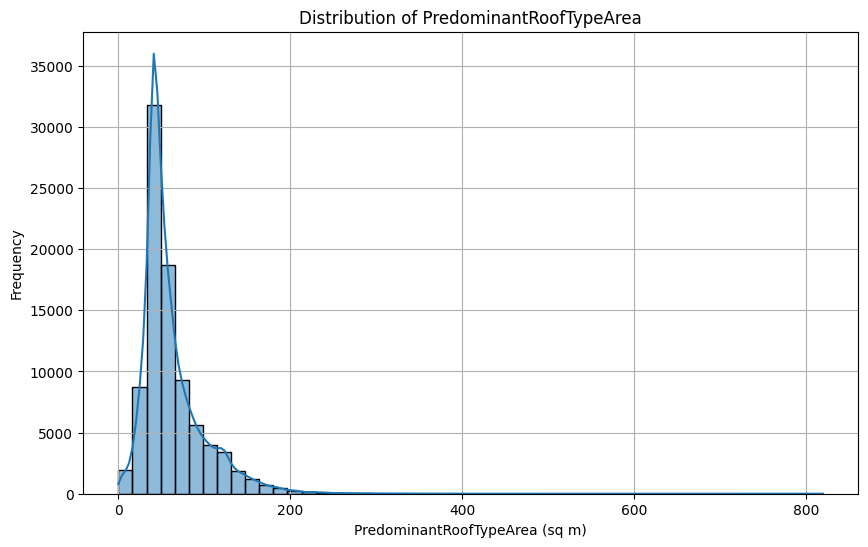

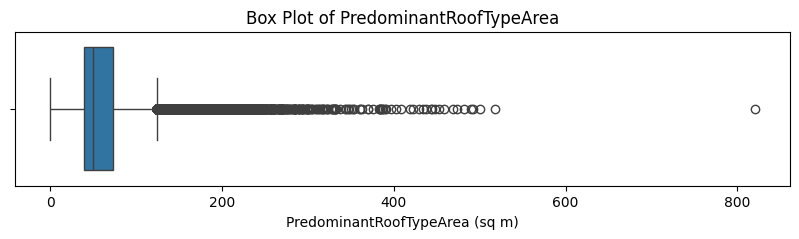

In [ ]:
# Get the 'PredominantRoofTypeArea' column from the DataFrame
roof_area = df['PredominantRoofTypeArea']

# Display descriptive statistics
print("Descriptive Statistics for PredominantRoofTypeArea:")
print(roof_area.describe())

# Plotting the distribution
plt.figure(figsize=(10, 6))
sns.histplot(roof_area, kde=True, bins=50)
plt.title('Distribution of PredominantRoofTypeArea')
plt.xlabel('PredominantRoofTypeArea (sq m)')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()

# Optionally, a box plot to see outliers and quartiles more clearly
plt.figure(figsize=(10, 2))
sns.boxplot(x=roof_area)
plt.title('Box Plot of PredominantRoofTypeArea')
plt.xlabel('PredominantRoofTypeArea (sq m)')
plt.show()

In [ ]:
from sklearn.impute import SimpleImputer

median_imputer = SimpleImputer(strategy="median")

df[numeric_cols] = median_imputer.fit_transform(df[numeric_cols])

##Categorical Imputation

In [ ]:
def inspect_no_none_usage(df, categorical_cols):
    results = []

    for col in categorical_cols:
        uniques = df[col].dropna().unique()

        uses_no = any(
            str(v).strip().lower() == "no" for v in uniques
        )
        uses_none = any(
            str(v).strip().lower() == "none" for v in uniques
        )

        if uses_no or uses_none:
            results.append({
                "column": col,
                "uses_No": uses_no,
                "uses_None": uses_none,
                "unique_values": uniques
            })

    return pd.DataFrame(results)

# Run it
usage_df = inspect_no_none_usage(df, categorical_cols)

usage_df


,column,uses_No,uses_None,unique_values
0,MultiDwellingMPRN,True,False,"[NO, YES]"
1,DraftLobby,True,False,"[NO, YES]"
2,SuspendedWoodenFloor,True,False,"[No, Yes (Sealed), Yes (Unsealed)]"
3,PermeabilityTest,True,False,"[NO, YES]"
4,CHBoilerThermostatControlled,True,False,"[YES, NO]"
5,OBBoilerThermostatControlled,True,False,"[YES, NO]"
6,OBPumpInsideDwelling,True,False,"[NO, YES]"
7,WarmAirHeatingSystem,True,False,"[NO, YES]"
8,UndergroundHeating,True,False,"[NO, YES]"
9,StorageLosses,True,False,"[YES, NO, nan]"


In [ ]:
impute_no = []
impute_none = []
impute_unknown = []

for col in categorical_cols:
    uniques = df[col].dropna().unique()
    lower_uniques = [str(u).strip().lower() for u in uniques]

    uses_no = "no" in lower_uniques
    uses_none = "none" in lower_uniques

    if uses_no and not uses_none:
        impute_no.append(col)
    elif uses_none and not uses_no:
        impute_none.append(col)
    else:
        impute_unknown.append(col)


In [ ]:
impute_no, impute_none, impute_unknown

(['MultiDwellingMPRN',
  'DraftLobby',
  'SuspendedWoodenFloor',
  'PermeabilityTest',
  'CHBoilerThermostatControlled',
  'OBBoilerThermostatControlled',
  'OBPumpInsideDwelling',
  'WarmAirHeatingSystem',
  'UndergroundHeating',
  'StorageLosses',
  'ManuLossFactorAvail',
  'SolarHotWaterHeating',
  'ElecImmersionInSummer',
  'CylinderStat',
  'CombinedCylinder',
  'SWHPumpSolarPowered'],
 ['CombiBoiler', 'KeepHotFacility', 'InsulationType'],
 ['CountyName',
  'DwellingTypeDescr',
  'TypeofRating',
  'EnergyRating',
  'MainSpaceHeatingFuel',
  'MainWaterHeatingFuel',
  'VentilationMethod',
  'StructureType',
  'ThermalMassCategory',
  'PredominantRoofType',
  'TGDLEdition',
  'SupplSHFuel',
  'SupplWHFuel',
  'SHRenewableResources',
  'WHRenewableResources',
  'HESSchemeUpgrade'])

In [ ]:
logical_zero_cols = [
    'HSSupplHeatFraction',
    'HSSupplSystemEff',
    'FanPowerManuDeclaredValue',
    'HeatExchangerEff'
]

for col in logical_zero_cols:
    if col in df.columns:
        df[col] = df[col].fillna(0)


In [ ]:
df[impute_no] = df[impute_no].fillna("NO")
df[impute_none] = df[impute_none].fillna("None")
df[impute_unknown] = df[impute_unknown].fillna("Unknown")

Removing rows that don't contain an energy rating

In [ ]:
original_len = len(df)
df = df[df["EnergyRating"] != "Unknown"]
new_len = len(df)

print(f"Removed {original_len - new_len} rows with unknown EnergyRating.")


Removed 0 rows with unknown EnergyRating.


In [ ]:
df.isna().sum().sum()


np.int64(0)

In [ ]:
df_clean = df.copy()
df_target = df["EnergyRating"]

In [ ]:
#df["CountyName"] = df["CountyName"].replace(
#    to_replace=r".*Dublin.*",
#    value="Co. Dublin",
#    regex=True
#)


In [ ]:
tree_df = df.copy()
logreg_df = df.copy()

logreg_df.drop(columns=["EnergyRating"], inplace=True)

print("Tree-based dataset shape:", tree_df.shape)
tree_df.head()


Tree-based dataset shape: (97421, 68)


,CountyName,DwellingTypeDescr,Year_of_Construction,TypeofRating,EnergyRating,GroundFloorArea(sq m),UValueWall,UValueRoof,UValueFloor,UValueWindow,...,SWHPumpSolarPowered,GroundFloorArea,GroundFloorHeight,FirstFloorArea,FirstFloorHeight,ThermalBridgingFactor,ThermalMassCategory,PredominantRoofTypeArea,PredominantRoofType,HESSchemeUpgrade
0,Co. Wexford,Detached house,2000.0,Existing,B3,233.78,0.28,0.23,0.41,2.71,...,NO,136.49,2.15,97.29,2.40,0.15,Medium,87.456,Pitch Roof-Insul.on Ceiling,1
1,Galway City,Semi-detached house,1982.0,Existing,C2,108.58,0.27,0.13,0.57,1.34,...,NO,54.29,2.40,54.29,2.70,0.15,Medium,54.290,Pitch Roof-Insul.on Ceiling,1
2,Co. Galway,Top-floor apartment,2002.0,Existing,C3,72.38,0.27,0.13,0.00,2.70,...,NO,72.38,2.50,0.00,0.00,0.15,Medium-low,72.380,Pitch Roof-Insul.on Ceiling,1
4,Co. Galway,Top-floor apartment,2002.0,Existing,D1,60.30,0.27,0.13,0.00,2.70,...,NO,60.30,2.45,0.00,0.00,0.15,Medium-low,60.300,Pitch Roof-Insul.on Ceiling,1
5,Co. Cork,Semi-detached house,1977.0,Existing,C3,123.70,0.42,0.13,0.84,2.86,...,NO,60.59,2.47,63.11,2.66,0.15,Medium,63.110,Pitch Roof-Insul.on Ceiling,1


In [ ]:
tree_df.columns.tolist()

['CountyName',
 'DwellingTypeDescr',
 'Year_of_Construction',
 'TypeofRating',
 'EnergyRating',
 'GroundFloorArea(sq m)',
 'UValueWall',
 'UValueRoof',
 'UValueFloor',
 'UValueWindow',
 'UvalueDoor',
 'WallArea',
 'RoofArea',
 'FloorArea',
 'WindowArea',
 'DoorArea',
 'NoStoreys',
 'MainSpaceHeatingFuel',
 'MainWaterHeatingFuel',
 'HSMainSystemEfficiency',
 'MultiDwellingMPRN',
 'TGDLEdition',
 'HSEffAdjFactor',
 'HSSupplHeatFraction',
 'SupplSHFuel',
 'SupplWHFuel',
 'SHRenewableResources',
 'WHRenewableResources',
 'NoOfChimneys',
 'NoOfOpenFlues',
 'NoOfFansAndVents',
 'DraftLobby',
 'VentilationMethod',
 'StructureType',
 'SuspendedWoodenFloor',
 'PercentageDraughtStripped',
 'NoOfSidesSheltered',
 'PermeabilityTest',
 'NoCentralHeatingPumps',
 'CHBoilerThermostatControlled',
 'NoOilBoilerHeatingPumps',
 'OBBoilerThermostatControlled',
 'OBPumpInsideDwelling',
 'NoGasBoilerHeatingPumps',
 'WarmAirHeatingSystem',
 'UndergroundHeating',
 'DistributionLosses',
 'StorageLosses',
 'Manu

#Encoding Categorical Features

In [ ]:
#not binary
impute_no.remove("SuspendedWoodenFloor")


binary_cols = impute_no

literally just all the different categorical columns to be encoded.

*Still need to go through this and clean it up*

In [ ]:
binary_cols = impute_no

categorical_to_onehot = [
    "SuspendedWoodenFloor",
    'CombiBoiler',
    'KeepHotFacility',
    'InsulationType',
    *impute_unknown
    ]

categorical_to_onehot.remove("EnergyRating")

In [ ]:
#Encoding binary fields
for col in binary_cols:
    logreg_df[col] = logreg_df[col].map({"Yes": 1, "No": 0})


In [ ]:
#One-hot encoding all categoricals
logreg_df = pd.get_dummies(
    logreg_df,
    columns=categorical_to_onehot,
    drop_first=False
)

print("Logistic Regression dataset shape:", logreg_df.shape)
logreg_df.head()


Logistic Regression dataset shape: (97421, 228)


,Year_of_Construction,GroundFloorArea(sq m),UValueWall,UValueRoof,UValueFloor,UValueWindow,UvalueDoor,WallArea,RoofArea,FloorArea,...,SHRenewableResources_nan,WHRenewableResources_1.0,WHRenewableResources_2.0,WHRenewableResources_3.0,WHRenewableResources_4.0,WHRenewableResources_5.0,WHRenewableResources_6.0,WHRenewableResources_nan,HESSchemeUpgrade_0,HESSchemeUpgrade_1
0,2000.0,233.78,0.28,0.23,0.41,2.71,3.00,137.89,157.26,136.49,...,False,False,True,False,False,False,False,False,False,True
1,1982.0,108.58,0.27,0.13,0.57,1.34,3.00,84.83,54.29,54.29,...,False,False,True,False,False,False,False,False,False,True
2,2002.0,72.38,0.27,0.13,0.00,2.70,0.00,51.98,72.38,0.00,...,False,False,True,False,False,False,False,False,False,True
4,2002.0,60.30,0.27,0.13,0.00,2.70,0.00,46.63,60.30,0.00,...,False,False,True,False,False,False,False,False,False,True
5,1977.0,123.70,0.42,0.13,0.84,2.86,1.66,117.01,63.11,60.59,...,False,False,True,False,False,False,False,False,False,True


In [ ]:
# ---- Drop zero-variance columns ----
zero_var_cols = [col for col in logreg_df.columns if logreg_df[col].nunique() <= 1]

if zero_var_cols:
    print(f"Dropping {len(zero_var_cols)} zero-variance columns:")
    print(zero_var_cols)
    logreg_df.drop(columns=zero_var_cols, inplace=True)
else:
    print("No zero-variance columns found.")

print("Logistic Regression dataset shape after cleanup:", logreg_df.shape)


Dropping 15 zero-variance columns:
['MultiDwellingMPRN', 'DraftLobby', 'PermeabilityTest', 'CHBoilerThermostatControlled', 'OBBoilerThermostatControlled', 'OBPumpInsideDwelling', 'WarmAirHeatingSystem', 'UndergroundHeating', 'StorageLosses', 'ManuLossFactorAvail', 'SolarHotWaterHeating', 'ElecImmersionInSummer', 'CylinderStat', 'CombinedCylinder', 'SWHPumpSolarPowered']
Logistic Regression dataset shape after cleanup: (97421, 213)


In [ ]:
logreg_df.columns.tolist()

['Year_of_Construction',
 'GroundFloorArea(sq m)',
 'UValueWall',
 'UValueRoof',
 'UValueFloor',
 'UValueWindow',
 'UvalueDoor',
 'WallArea',
 'RoofArea',
 'FloorArea',
 'WindowArea',
 'DoorArea',
 'NoStoreys',
 'HSMainSystemEfficiency',
 'HSEffAdjFactor',
 'HSSupplHeatFraction',
 'NoOfChimneys',
 'NoOfOpenFlues',
 'NoOfFansAndVents',
 'PercentageDraughtStripped',
 'NoOfSidesSheltered',
 'NoCentralHeatingPumps',
 'NoOilBoilerHeatingPumps',
 'NoGasBoilerHeatingPumps',
 'DistributionLosses',
 'WaterStorageVolume',
 'InsulationThickness',
 'GroundFloorArea',
 'GroundFloorHeight',
 'FirstFloorArea',
 'FirstFloorHeight',
 'ThermalBridgingFactor',
 'PredominantRoofTypeArea',
 'SuspendedWoodenFloor_No',
 'SuspendedWoodenFloor_Yes (Sealed)',
 'SuspendedWoodenFloor_Yes (Unsealed)',
 'CombiBoiler_Instantaneous, with keep-hot f',
 'CombiBoiler_Instantaneous, without keep-ho',
 'CombiBoiler_None',
 'CombiBoiler_Storage combi boiler store vol',
 'CombiBoiler_nan',
 'KeepHotFacility_None',
 'KeepHot

In [ ]:
#Validating
print("Remaining object columns:", logreg_df.select_dtypes(include=["object"]).columns.tolist())


Remaining object columns: []


In [ ]:
tree_df.isna().sum().sum() == 0


np.True_

#Preparing for modelling + 5 Baselines

In [ ]:
rating_order = ['A','B1','B2','B3','C1','C2','C3','D1','D2','E1','E2','F','G']
rating_to_num = {label: idx for idx, label in enumerate(rating_order)}


#### Tree based models

In [ ]:
from sklearn.model_selection import train_test_split

# Tree-based target
tree_y = tree_df['EnergyRating'].map(rating_to_num)
tree_X = tree_df.drop(columns=["EnergyRating"])

X_tree_train, X_tree_test, y_tree_train, y_tree_test = train_test_split(
    tree_X,
    tree_y,
    test_size=0.20,
    random_state=42,
    stratify=tree_y
)

#Identify categorical features
cat_features = X_tree_train.select_dtypes(include=["object"]).columns.tolist()

#Ensure the correct data types
for col in cat_features:
    X_tree_train[col] = X_tree_train[col].astype("category")
    X_tree_test[col] = X_tree_test[col].astype("category")



#### LogReg models

In [ ]:
# LogReg target
y_logreg = df_target.map(rating_to_num)

X_logreg_train, X_logreg_test, y_logreg_train, y_logreg_test = train_test_split(
    logreg_df,
    y_logreg,
    test_size=0.20,
    random_state=42,
    stratify=y_logreg
)

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

scaler.fit(X_logreg_train)

X_logreg_train_scaled = scaler.transform(X_logreg_train)
X_logreg_test_scaled  = scaler.transform(X_logreg_test)

##ordinal logistic regression (baseline)

In [ ]:
!pip install mord


  Preparing metadata (setup.py) ... done
  Created wheel for mord: filename=mord-0.7-py3-none-any.whl size=9885 sha256=76ade29abac28e58dd627d400731eb02d56dc1435adaffdc455af02d5344ea99
  Stored in directory: /root/.cache/pip/wheels/80/3e/3b/13f1adf346cad0fec675db328e4b0d814795c6c8e2fb659122
Successfully built mord


In [ ]:
import mord as m

#Training
model_ordlog = m.LogisticAT(alpha=1.0)

model_ordlog.fit(X_logreg_train_scaled, y_logreg_train)


LogisticAT()

In [ ]:
#predicting
y_pred_ordlog = model_ordlog.predict(X_logreg_test_scaled)


In [ ]:
from sklearn.metrics import cohen_kappa_score, accuracy_score, confusion_matrix

kappa = cohen_kappa_score(y_logreg_test, y_pred_ordlog, weights='quadratic')
print("Quadratic Weighted Kappa:", round(kappa, 4))

accuracy = accuracy_score(y_logreg_test, y_pred_ordlog)
print("Accuracy:", round(accuracy, 4))

Quadratic Weighted Kappa: 0.9512
Accuracy: 0.5042


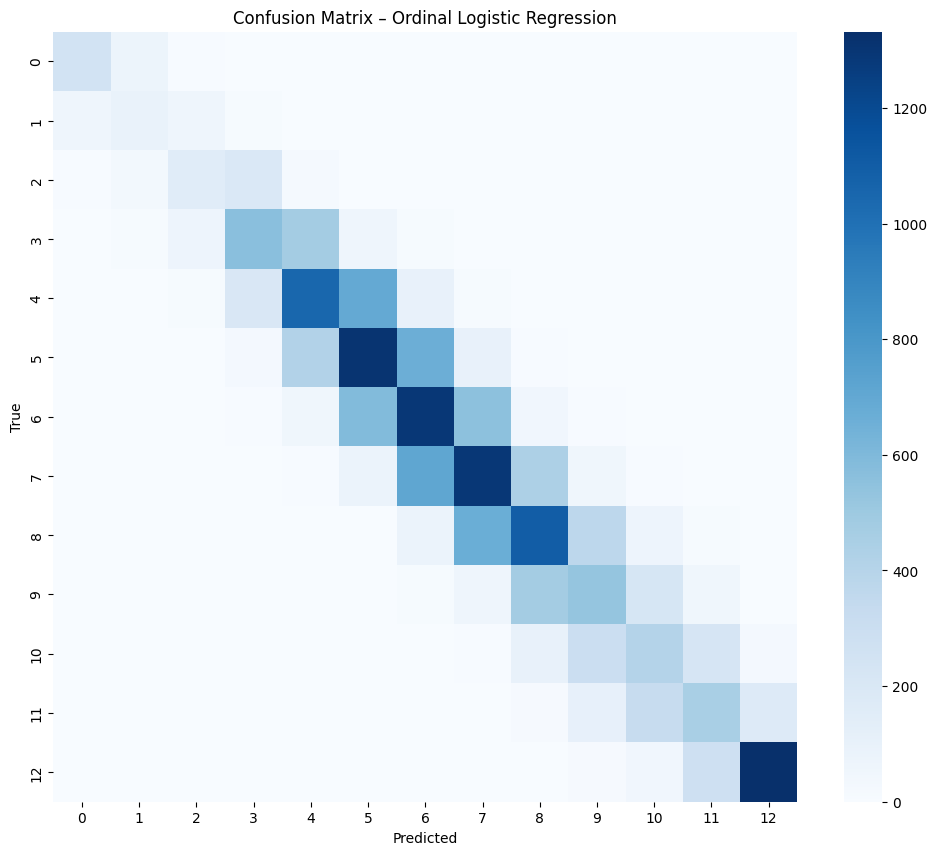

In [ ]:
cm = confusion_matrix(y_logreg_test, y_pred_ordlog)

plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=False, cmap="Blues")
plt.title("Confusion Matrix – Ordinal Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

# Mulitnomial logistic regression (non-ordinal baseline)

In [ ]:
from sklearn.linear_model import LogisticRegression

# Multinomial logistic regression model
model_multinom = LogisticRegression(
    multi_class="multinomial",
    solver="lbfgs",
    max_iter=500,
    n_jobs=-1
)

# Train the model
model_multinom.fit(X_logreg_train_scaled, y_logreg_train)


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


LogisticRegression(max_iter=500, multi_class='multinomial', n_jobs=-1)

In [ ]:
#predictions
y_pred_multinom = model_multinom.predict(X_logreg_test_scaled)


In [ ]:
kappa = cohen_kappa_score(y_logreg_test, y_pred_multinom, weights='quadratic')
print("Quadratic Weighted Kappa:", round(kappa, 4))

accuracy = accuracy_score(y_logreg_test, y_pred_multinom)
print("Accuracy:", round(accuracy, 4))

Quadratic Weighted Kappa: 0.9592
Accuracy: 0.5605


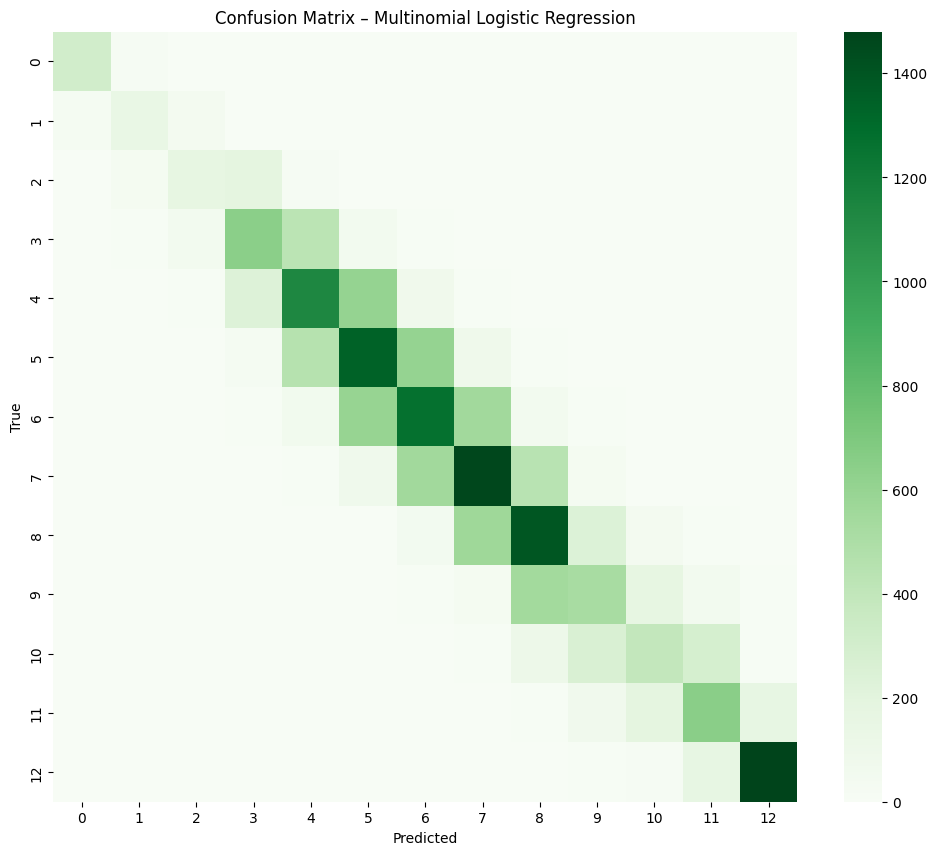

In [ ]:
cm_multi = confusion_matrix(y_logreg_test, y_pred_multinom)

plt.figure(figsize=(12, 10))
sns.heatmap(cm_multi, annot=False, cmap="Greens")
plt.title("Confusion Matrix – Multinomial Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

# Random Forest

tune both ordinal and multiclass of each model

In [ ]:
from sklearn.ensemble import RandomForestClassifier

model_rf_class = RandomForestClassifier(
    n_estimators=500,
    max_depth=20,
    min_samples_split=2,
    min_samples_leaf=1,
    max_features="sqrt",
    bootstrap=True,
    random_state=42,
    n_jobs=-1
)

model_rf_class.fit(
    X_logreg_train,
    y_logreg_train
)

RandomForestClassifier(max_depth=20, n_estimators=500, n_jobs=-1,
                       random_state=42)

In [ ]:
# Multiclass predictions (class indices)
y_pred_rf_class = model_rf_class.predict(X_logreg_test)

In [ ]:
from sklearn.ensemble import RandomForestRegressor

model_rf_ord = RandomForestRegressor(
    n_estimators=500,
    max_depth=20,
    min_samples_split=2,
    min_samples_leaf=1,
    max_features="sqrt",
    bootstrap=True,
    random_state=42,
    n_jobs=-1
)

model_rf_ord.fit(
    X_logreg_train,
    y_logreg_train
)


RandomForestRegressor(max_depth=20, max_features='sqrt', n_estimators=500,
                      n_jobs=-1, random_state=42)

In [ ]:
# Continuous predictions
y_pred_cont_rf_ord = model_rf_ord.predict(X_logreg_test)

# Convert to ordinal class indices
y_pred_rf_ord = (
    np.round(y_pred_cont_rf_ord)
    .clip(0, max(rating_to_num.values()))
    .astype(int)
)


============= RANDOM FOREST PERFORMANCE =============

Random Forest – Multiclass:
  QWK:       0.9435
  Accuracy:  0.5122

Random Forest – Ordinal:
  QWK:       0.9440
  Accuracy:  0.4686



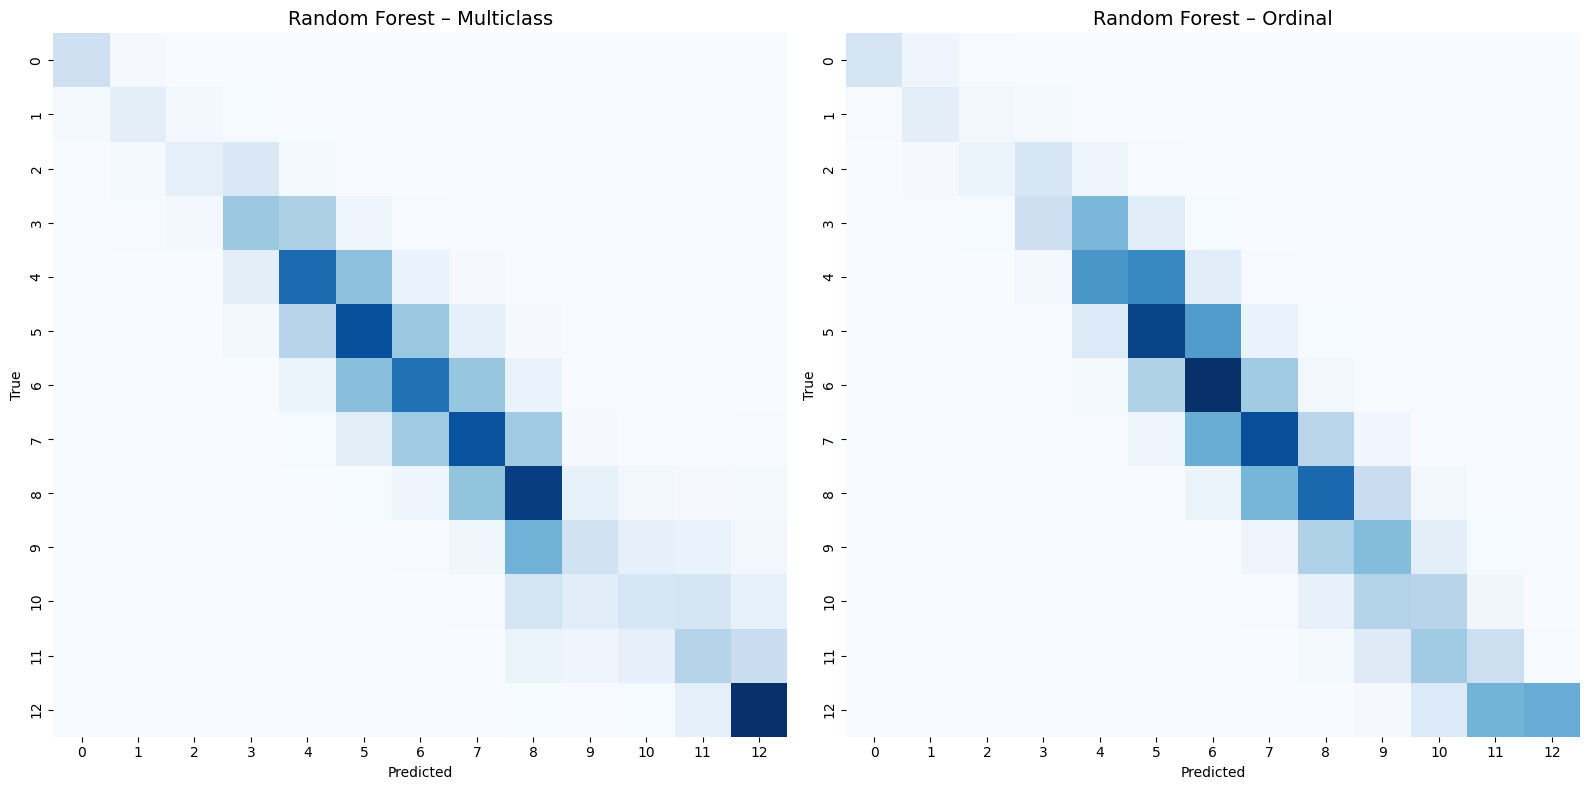

In [ ]:

rf_models = {
    "Random Forest – Multiclass": y_pred_rf_class,
    "Random Forest – Ordinal":    y_pred_rf_ord
}

rf_results = {}

print("\n============= RANDOM FOREST PERFORMANCE =============\n")

# ---- Random Forest: Multiclass ----
qwk_rf_class = cohen_kappa_score(y_logreg_test, y_pred_rf_class, weights="quadratic")
acc_rf_class = accuracy_score(y_logreg_test, y_pred_rf_class)

print("Random Forest – Multiclass:")
print(f"  QWK:       {qwk_rf_class:.4f}")
print(f"  Accuracy:  {acc_rf_class:.4f}\n")


# ---- Random Forest: Ordinal ----
qwk_rf_ord = cohen_kappa_score(y_logreg_test, y_pred_rf_ord, weights="quadratic")
acc_rf_ord = accuracy_score( y_logreg_test, y_pred_rf_ord)

print("Random Forest – Ordinal:")
print(f"  QWK:       {qwk_rf_ord:.4f}")
print(f"  Accuracy:  {acc_rf_ord:.4f}\n")


# Confusion Matrices

fig, axes = plt.subplots(1, 2, figsize=(16, 8))

for ax, (name, pred) in zip(axes, rf_models.items()):
    cm = confusion_matrix(y_logreg_test, pred)
    sns.heatmap(cm, cmap="Blues", ax=ax, cbar=False)
    ax.set_title(name, fontsize=14)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")

plt.tight_layout()
plt.show()


# CatBoost

In [ ]:
!pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.2/99.2 MB 11.8 MB/s eta 0:00:00


In [ ]:
from catboost import CatBoostClassifier

model_cat_class = CatBoostClassifier(
    loss_function="MultiClass",
    eval_metric="MultiClass",
    iterations=2000,
    learning_rate=0.03,
    depth=8,
    l2_leaf_reg=5,
    random_seed=42,
    task_type="GPU",
    verbose=200,
    early_stopping_rounds=100
)

model_cat_class.fit(
    X_tree_train,
    y_tree_train,
    cat_features=cat_features,
    eval_set=(X_tree_test, y_tree_test),
    use_best_model=True
)

0:	learn: 2.5035283	test: 2.5039271	best: 2.5039271 (0)	total: 249ms	remaining: 8m 16s
200:	learn: 1.2123625	test: 1.2422913	best: 1.2422913 (200)	total: 36.2s	remaining: 5m 23s
400:	learn: 1.0598257	test: 1.1213028	best: 1.1213028 (400)	total: 47.1s	remaining: 3m 7s
600:	learn: 0.9826022	test: 1.0702965	best: 1.0702965 (600)	total: 55.6s	remaining: 2m 9s
800:	learn: 0.9316848	test: 1.0385984	best: 1.0385984 (800)	total: 1m 5s	remaining: 1m 38s
1000:	learn: 0.8919039	test: 1.0161605	best: 1.0161605 (1000)	total: 1m 15s	remaining: 1m 15s
1200:	learn: 0.8595702	test: 0.9992863	best: 0.9992863 (1200)	total: 1m 23s	remaining: 55.4s
1400:	learn: 0.8312320	test: 0.9859813	best: 0.9859813 (1400)	total: 1m 33s	remaining: 39.8s
1600:	learn: 0.8060169	test: 0.9750504	best: 0.9750504 (1600)	total: 1m 42s	remaining: 25.6s
1800:	learn: 0.7841986	test: 0.9659026	best: 0.9659026 (1800)	total: 1m 50s	remaining: 12.2s
1999:	learn: 0.7622979	test: 0.9578864	best: 0.9578864 (1999)	total: 2m	remaining: 0u

In [ ]:
# Multiclass predictions (class indices)
y_pred_cat_class = model_cat_class.predict(X_tree_test).astype(int)

In [ ]:
from catboost import CatBoostRegressor

model_cat_ord = CatBoostRegressor(
    loss_function="RMSE",
    eval_metric="RMSE",
    iterations=2000,
    learning_rate=0.03,
    depth=8,
    l2_leaf_reg=5,
    random_seed=42,
    task_type="GPU",
    verbose=200,
    early_stopping_rounds=100
)

model_cat_ord.fit(
    X_tree_train,
    y_tree_train,
    cat_features=cat_features,
    eval_set=(X_tree_test, y_tree_test),
    use_best_model=True
)

0:	learn: 2.8195138	test: 2.8198729	best: 2.8198729 (0)	total: 165ms	remaining: 5m 29s
200:	learn: 0.7567924	test: 0.7758310	best: 0.7758310 (200)	total: 28.3s	remaining: 4m 13s
400:	learn: 0.6601950	test: 0.6852114	best: 0.6852114 (400)	total: 43.5s	remaining: 2m 53s
600:	learn: 0.6137468	test: 0.6435401	best: 0.6435401 (600)	total: 54.9s	remaining: 2m 7s
800:	learn: 0.5859422	test: 0.6198506	best: 0.6198506 (800)	total: 1m 4s	remaining: 1m 36s
1000:	learn: 0.5658018	test: 0.6035155	best: 0.6035155 (1000)	total: 1m 14s	remaining: 1m 13s
1200:	learn: 0.5499409	test: 0.5915654	best: 0.5915654 (1200)	total: 1m 21s	remaining: 54.4s
1400:	learn: 0.5374208	test: 0.5828796	best: 0.5828796 (1400)	total: 1m 31s	remaining: 39s
1600:	learn: 0.5262082	test: 0.5752797	best: 0.5752797 (1600)	total: 1m 40s	remaining: 25.1s
1800:	learn: 0.5168309	test: 0.5697389	best: 0.5697389 (1800)	total: 1m 48s	remaining: 11.9s
1999:	learn: 0.5086066	test: 0.5652625	best: 0.5652625 (1999)	total: 1m 58s	remaining:

In [ ]:
# Ordinal predictions
y_pred_cat_ord = model_cat_ord.predict(X_tree_test).astype(int)

# LightGBM

In [ ]:
!pip install lightgbm

In [ ]:
import lightgbm as lgb

# ---- LightGBM model ----
model_lgb_ord = lgb.LGBMRegressor(
    objective="regression",
    metric="rmse",
    n_estimators=2000,
    learning_rate=0.03,
    max_depth=8,
    reg_lambda=5,
    random_state=42
)

# Fit using sklearn API
model_lgb_ord.fit(
    X_tree_train,
    y_tree_train,
    eval_set=[(X_tree_test, y_tree_test)],
    eval_metric="rmse",
    categorical_feature=cat_features,
    callbacks=[
        lgb.early_stopping(stopping_rounds=100, verbose=True)
    ]
)


# Predict continuous output
y_pred_cont_lgb_ord = model_lgb_ord.predict(X_tree_test)

# Round to ordinal class index
y_pred_lgb_ord = (
    np.round(y_pred_cont_lgb_ord)
    .clip(0, max(rating_to_num.values()))
    .astype(int)
)

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.062149 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 5256
[LightGBM] [Info] Number of data points in the train set: 77936, number of used features: 67
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Start training from score 6.820288
Training until validation scores don't improve for 100 rounds
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -i

In [ ]:
import lightgbm as lgb

num_classes = len(rating_order)

model_lgb_class = lgb.LGBMClassifier(
    objective="multiclass",
    num_class=num_classes,
    metric="multi_logloss",
    n_estimators=2000,
    learning_rate=0.03,
    max_depth=8,
    reg_lambda=5,
    random_state=42
)

model_lgb_class.fit(
    X_tree_train,
    y_tree_train,
    eval_set=[(X_tree_test, y_tree_test)],
    categorical_feature=cat_features,
    callbacks=[lgb.early_stopping(stopping_rounds=100)]
)

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.103612 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 5256
[LightGBM] [Info] Number of data points in the train set: 77936, number of used features: 67
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Start training from score -4.067706
[LightGBM] [Info] Start training from score -4.418828
[LightGBM] [Info] Start training from score -3.837690
[LightGBM] [Info] Start training from score -2.781249
[LightGBM] [Info] Start training from score -2.240356
[LightGBM] [Info] Start training from score -2.039992
[LightGBM] [Info] Start training from score -2.031639
[LightGBM] [Info] Start training from score -2.011489
[LightGBM] [Info] Start training from score -2.128673
[

LGBMClassifier(learning_rate=0.03, max_depth=8, metric='multi_logloss',
               n_estimators=2000, num_class=13, objective='multiclass',
               random_state=42, reg_lambda=5)

In [ ]:
y_pred_lgb_class = model_lgb_class.predict(X_tree_test)

,count
EnergyRating,
D1,13034
C3,12774
C2,12668
D2,11592
C1,10368
G,8384
E1,6799
B3,6036
F,5470


# XGBoost

In [ ]:
from sklearn.preprocessing import LabelEncoder

tree_df_encoded = tree_df.copy()

cat_cols = tree_df_encoded.select_dtypes(include=["object", "category"]).columns.drop("EnergyRating")

label_encoders = {}

for col in cat_cols:
    le = LabelEncoder()
    tree_df_encoded[col] = le.fit_transform(tree_df_encoded[col].astype(str))
    label_encoders[col] = le

X = tree_df_encoded.drop(columns=["EnergyRating"])
y = tree_df_encoded["EnergyRating"].map(rating_to_num)

X_tree_train_enc, X_tree_test_enc, y_tree_train_enc, y_tree_test_enc = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)


In [ ]:
import xgboost as xgb

model_xgb_ord = xgb.XGBRegressor(
    objective="reg:squarederror",
    n_estimators=2000,
    learning_rate=0.03,
    max_depth=8,
    reg_lambda=5,
    subsample=0.9,
    colsample_bytree=0.9,
    tree_method="hist",  # CPU-compatible fast histogram algorithm
    random_state=42
)

model_xgb_ord.fit(
    X_tree_train_enc,
    y_tree_train_enc,
    eval_set=[(X_tree_test_enc, y_tree_test_enc)],
    verbose=200
)

# ---- Predictions ----
y_pred_cont_xgb_ord = model_xgb_ord.predict(X_tree_test_enc)

# Convert continuous → ordinal class
y_pred_xgb_ord = (
    np.round(y_pred_cont_xgb_ord)
    .clip(0, max(rating_to_num.values()))
    .astype(int)
)


[0]	validation_0-rmse:2.81401
[200]	validation_0-rmse:0.68675
[400]	validation_0-rmse:0.62279
[600]	validation_0-rmse:0.59889
[800]	validation_0-rmse:0.58665
[1000]	validation_0-rmse:0.57847
[1200]	validation_0-rmse:0.57335
[1400]	validation_0-rmse:0.56988
[1600]	validation_0-rmse:0.56748
[1800]	validation_0-rmse:0.56587
[1999]	validation_0-rmse:0.56455


In [ ]:
num_classes = len(rating_order)

model_xgb_class = xgb.XGBClassifier(
    objective="multi:softmax",
    num_class=num_classes,
    n_estimators=2000,
    learning_rate=0.03,
    max_depth=8,
    reg_lambda=5,
    subsample=0.9,
    colsample_bytree=0.9,
    tree_method="hist",
    random_state=42,
    eval_metric="mlogloss"
)

model_xgb_class.fit(
    X_tree_train_enc,
    y_tree_train_enc,
    eval_set=[(X_tree_test_enc, y_tree_test_enc)],
    verbose=200
)



[0]	validation_0-mlogloss:2.49861
[200]	validation_0-mlogloss:1.21241
[400]	validation_0-mlogloss:1.08298
[600]	validation_0-mlogloss:1.03046
[800]	validation_0-mlogloss:1.00176
[1000]	validation_0-mlogloss:0.98519
[1200]	validation_0-mlogloss:0.97457
[1400]	validation_0-mlogloss:0.96837
[1600]	validation_0-mlogloss:0.96542
[1800]	validation_0-mlogloss:0.96492
[1999]	validation_0-mlogloss:0.96578


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.9, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='mlogloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.03, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=8, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=2000, n_jobs=None, num_class=13, ...)

In [ ]:
y_pred_xgb_class = model_xgb_class.predict(X_tree_test_enc)

# EVALUATION


================= MODEL PERFORMANCE =================

XGBoost – Multiclass:
  QWK:       0.9639
  Accuracy:  0.5889

XGBoost – Ordinal:
  QWK:       0.9761
  Accuracy:  0.6641

LightGBM – Multiclass:
  QWK:       0.9620
  Accuracy:  0.5745

LightGBM – Ordinal:
  QWK:       0.9758
  Accuracy:  0.6546

CatBoost – Multiclass:
  QWK:       0.9639
  Accuracy:  0.6020

CatBoost – Ordinal:
  QWK:       0.9602
  Accuracy:  0.4668


================= RANKING BY QWK (BEST → WORST) =================

1. XGBoost – Ordinal          QWK = 0.9761
2. LightGBM – Ordinal         QWK = 0.9758
3. XGBoost – Multiclass       QWK = 0.9639
4. CatBoost – Multiclass      QWK = 0.9639
5. LightGBM – Multiclass      QWK = 0.9620
6. CatBoost – Ordinal         QWK = 0.9602


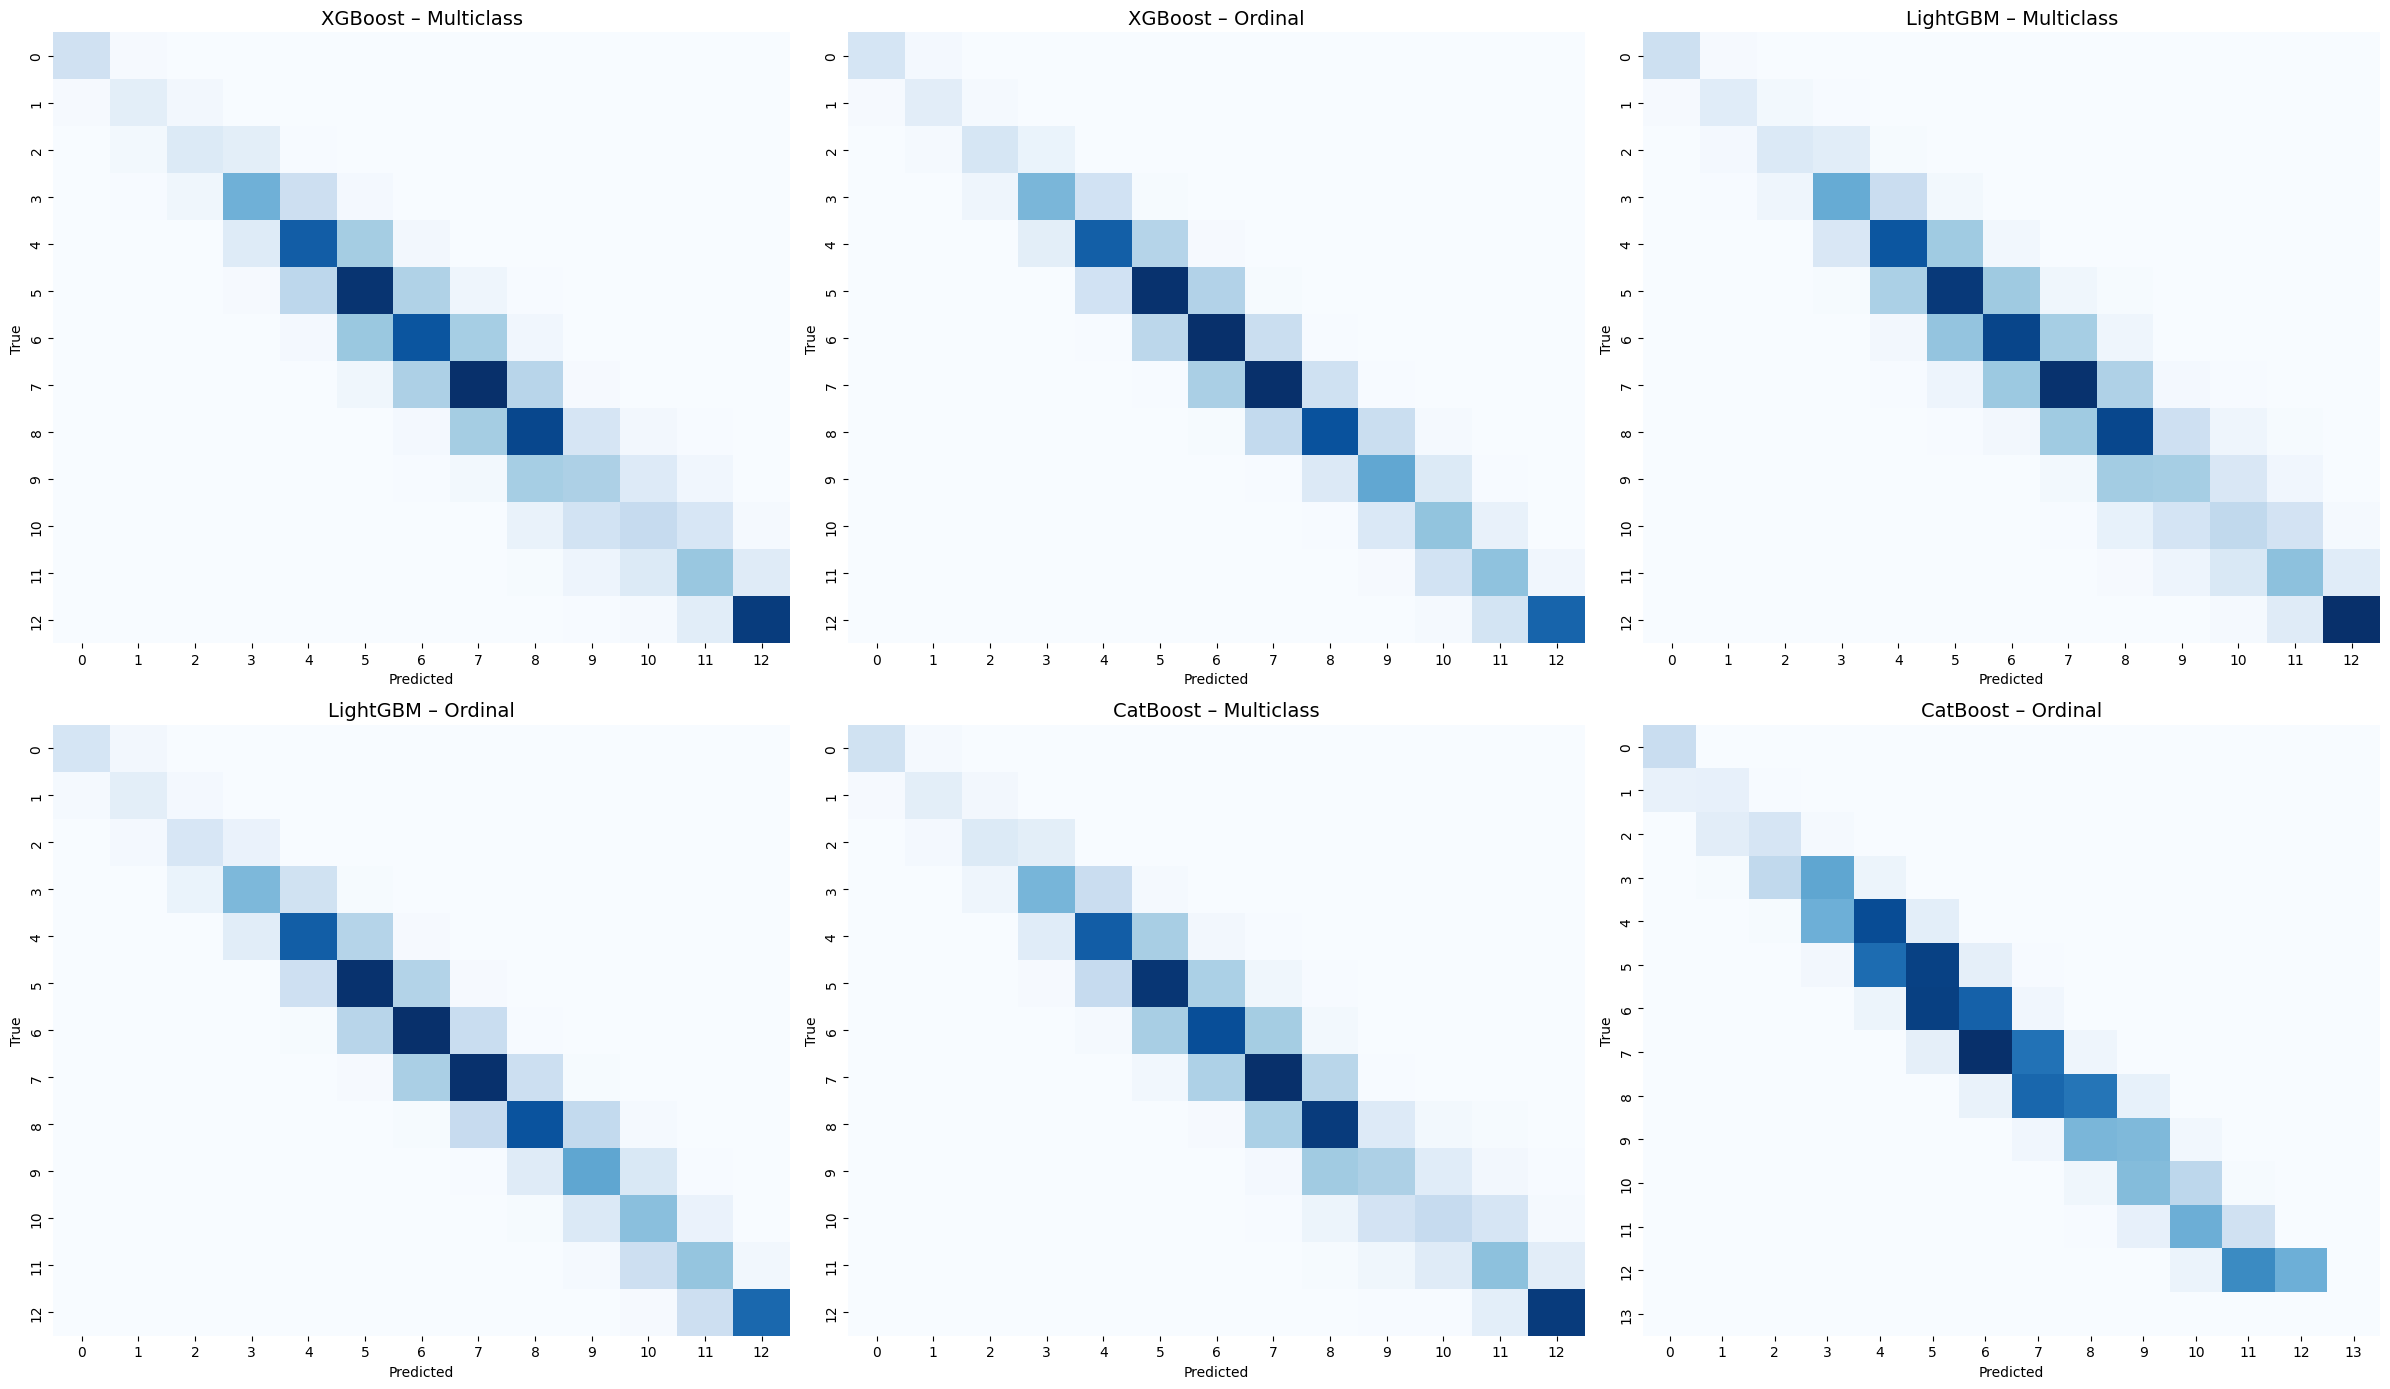

In [ ]:

# STORE ALL MODEL PREDICTIONS
models = {
    "XGBoost – Multiclass": y_pred_xgb_class,
    "XGBoost – Ordinal":    y_pred_xgb_ord,
    "LightGBM – Multiclass": y_pred_lgb_class,
    "LightGBM – Ordinal":    y_pred_lgb_ord,
    "CatBoost – Multiclass": y_pred_cat_class,
    "CatBoost – Ordinal":    y_pred_cat_ord
}


# PRINT QWK + ACCURACY FOR EACH MODEL
results = {}

print("\n================= MODEL PERFORMANCE =================\n")
for name, pred in models.items():
    qwk = cohen_kappa_score(y_tree_test, pred, weights='quadratic')
    acc = accuracy_score(y_tree_test, pred)

    results[name] = {"QWK": qwk, "Accuracy": acc}

    print(f"{name}:")
    print(f"  QWK:       {qwk:.4f}")
    print(f"  Accuracy:  {acc:.4f}\n")


# RANK MODELS BY QWK
ranked = sorted(results.items(), key=lambda x: x[1]["QWK"], reverse=True)

print("\n================= RANKING BY QWK (BEST → WORST) =================\n")
for i, (model_name, metrics) in enumerate(ranked, start=1):
    print(f"{i}. {model_name:25s}  QWK = {metrics['QWK']:.4f}")


# CONFUSION MATRICES (2x3 GRID)
fig, axes = plt.subplots(2, 3, figsize=(24, 14))
axes = axes.flatten()

for ax, (name, pred) in zip(axes, models.items()):
    cm = confusion_matrix(y_tree_test, pred)
    sns.heatmap(cm, cmap="Blues", ax=ax, cbar=False)
    ax.set_title(name, fontsize=14)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")

plt.tight_layout()
plt.show()


# Feature block selection

In [ ]:
feature_blocks = {
    "metadata": [
        "CountyName", "DwellingTypeDescr", "Year_of_Construction",
        "TypeofRating", "NoStoreys", "StructureType", "HESSchemeUpgrade", "MultiDwellingMPRN"
    ],
    "geometry": [
        "GroundFloorArea(sq m)", "WallArea", "RoofArea", "FloorArea",
        "WindowArea", "DoorArea", "GroundFloorArea", "GroundFloorHeight",
        "FirstFloorArea", "FirstFloorHeight", "PredominantRoofTypeArea", "SuspendedWoodenFloor"
    ],
    "fabric": [
        "UValueWall", "UValueRoof", "UValueFloor", "UValueWindow",
        "UvalueDoor", "ThermalBridgingFactor", "ThermalMassCategory",
        "PredominantRoofType"
    ],
    "ventilation": [
        "VentilationMethod", "DraftLobby", "NoOfFansAndVents",
        "NoOfChimneys", "NoOfOpenFlues", "NoOfSidesSheltered",
        "PermeabilityTest", "PercentageDraughtStripped"
    ],
    "heating_type": [
      "MainSpaceHeatingFuel",
      "MainWaterHeatingFuel",
      "SupplSHFuel",
      "SupplWHFuel",
      "UndergroundHeating"
    ],
    "heating_control": [
        "NoCentralHeatingPumps", "CHBoilerThermostatControlled",
        "NoOilBoilerHeatingPumps", "OBBoilerThermostatControlled",
        "OBPumpInsideDwelling", "NoGasBoilerHeatingPumps",
        "WarmAirHeatingSystem", "CombiBoiler", "KeepHotFacility",
        "CylinderStat", "CombinedCylinder"
    ],
    "hot_water": [
        "SolarHotWaterHeating", "ElecImmersionInSummer",
        "WaterStorageVolume", "InsulationType", "InsulationThickness"
    ],
    "renewables": [
      "SHRenewableResources", "WHRenewableResources", "SWHPumpSolarPowered"
    ],
    "efficiency_losses": [
        "HSMainSystemEfficiency", "TGDLEdition", "HSEffAdjFactor",
        "HSSupplHeatFraction", "DistributionLosses", "StorageLosses",
        "ManuLossFactorAvail"
    ]
}


In [ ]:
#baseline metrics

baseline_qwk = cohen_kappa_score(y_tree_test, y_pred_lgb_ord, weights="quadratic")
baseline_acc = accuracy_score(y_tree_test, y_pred_lgb_ord)

results = [{
    "Feature Configuration": "All Features",
    "QWK": baseline_qwk,
    "Accuracy": baseline_acc,
    "Δ QWK vs All": 0.0,
    "Δ Accuracy": 0.0
}]


In [ ]:

#  train LightGBM ordinal + return QWK & Accuracy

def run_lgb_ordinal(X_train, X_valid, y_train, y_valid, cat_cols, random_state=42):
    model = lgb.LGBMRegressor(
        objective="regression",
        metric="rmse",
        n_estimators=2000,
        learning_rate=0.03,
        max_depth=8,
        reg_lambda=5,
        random_state=random_state
    )

    model.fit(
        X_train,
        y_train,
        eval_set=[(X_valid, y_valid)],
        eval_metric="rmse",
        categorical_feature=cat_cols,
        callbacks=[lgb.early_stopping(stopping_rounds=100, verbose=False)]
    )

    # Continuous → ordinal class
    y_pred_cont = model.predict(X_valid)
    max_class = int(max(y_train.max(), y_valid.max()))
    y_pred = (
        np.round(y_pred_cont)
        .clip(0, max_class)
        .astype(int)
    )

    qwk = cohen_kappa_score(y_valid, y_pred, weights="quadratic")
    acc = accuracy_score(y_valid, y_pred)
    return qwk, acc



In [ ]:

# Remove-One-Block
all_features = X_tree_train.columns.tolist()
cat_all = [c for c in cat_features if c in all_features]

for block_name, cols in feature_blocks.items():
    # Make sure we only drop columns that actually exist
    cols_to_remove = [c for c in cols if c in all_features]
    remaining_features = [c for c in all_features if c not in cols_to_remove]
    cat_remaining = [c for c in cat_features if c in remaining_features]

    qwk, acc = run_lgb_ordinal(
        X_tree_train[remaining_features],
        X_tree_test[remaining_features],
        y_tree_train,
        y_tree_test,
        cat_remaining
    )

    results.append({
        "Feature Configuration": f"All minus {block_name}",
        "QWK": qwk,
        "Accuracy": acc,
        "Δ QWK vs All": qwk - baseline_qwk,
        "Δ Accuracy": acc - baseline_acc
    })


[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.028657 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 4991
[LightGBM] [Info] Number of data points in the train set: 77936, number of used features: 59
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Start training from score 6.820288
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Info] Auto-choosing row-wise multi-threading, t

In [ ]:
results_df = pd.DataFrame(results)
results_df

,Feature Configuration,QWK,Accuracy,Δ QWK vs All,Δ Accuracy
0,All Features,0.975844,0.654606,0.000000,0.000000
1,All minus metadata,0.975863,0.655684,0.000019,0.001078
2,All minus geometry,0.966386,0.594663,-0.009458,-0.059944
3,All minus fabric,0.939452,0.486220,-0.036392,-0.168386
4,All minus ventilation,0.973261,0.628381,-0.002583,-0.026225
5,All minus heating_type,0.974830,0.646805,-0.001014,-0.007801
6,All minus heating_control,0.974988,0.647986,-0.000856,-0.006620
7,All minus hot_water,0.971087,0.619707,-0.004757,-0.034899
8,All minus renewables,0.975886,0.654657,0.000042,0.000051
9,All minus efficiency_losses,0.958299,0.531486,-0.017545,-0.123120


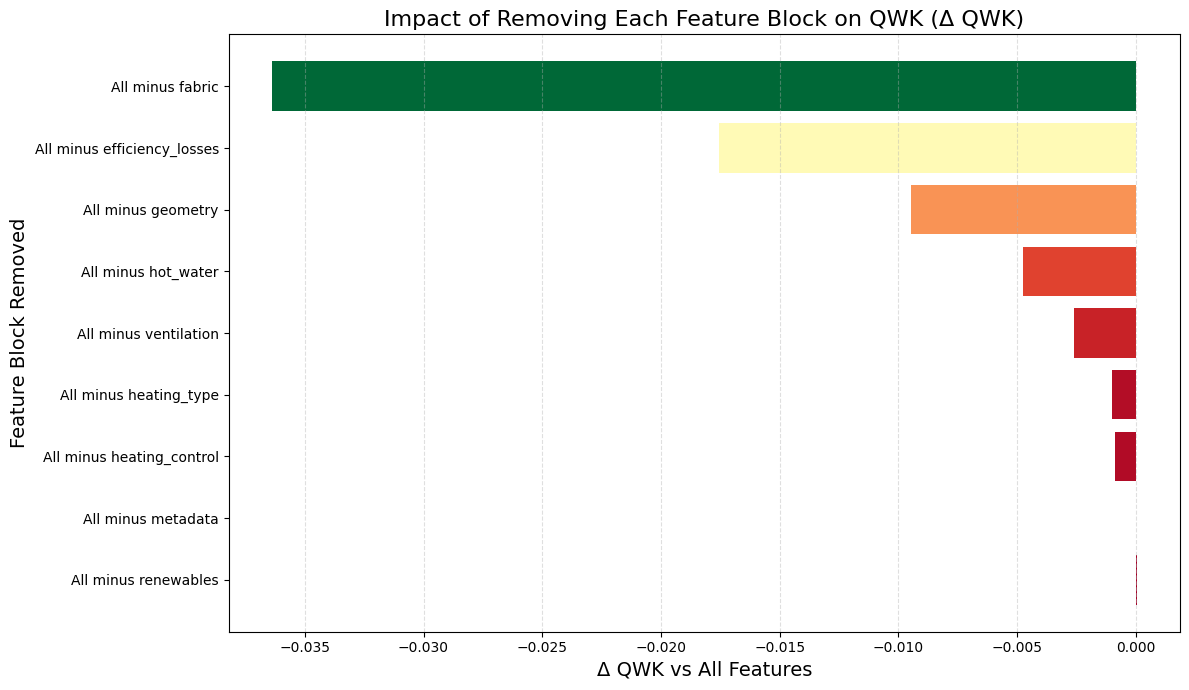

In [ ]:
# Sort blocks from most to least important (largest negative Δ QWK)
plot_df = results_df.copy()
plot_df = plot_df[plot_df["Feature Configuration"] != "All Features"]
plot_df = plot_df.sort_values("Δ QWK vs All", ascending=False)

# Normalise Δ QWK for colour mapping
vals = plot_df["Δ QWK vs All"].values
norm = (vals - vals.min()) / (vals.max() - vals.min())

# Correct BER-style colormap (green → red)
colors = plt.cm.RdYlGn_r(norm)

# Plot
plt.figure(figsize=(12, 7))
bars = plt.barh(plot_df["Feature Configuration"], plot_df["Δ QWK vs All"], color=colors)

plt.title("Impact of Removing Each Feature Block on QWK (Δ QWK)", fontsize=16)
plt.xlabel("Δ QWK vs All Features", fontsize=14)
plt.ylabel("Feature Block Removed", fontsize=14)

plt.grid(axis='x', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()


In [ ]:
best_blocks = (
    feature_blocks["fabric"]
    + feature_blocks["efficiency_losses"]
    + feature_blocks["geometry"]
    + feature_blocks["hot_water"]
    + feature_blocks["ventilation"]
)

X_train_red = X_tree_train[best_blocks]
X_test_red  = X_tree_test[best_blocks]

# hyper-parameter tuning

In [ ]:
# Remove categorical features that don't exist in the reduced set
cat_features_red = [c for c in cat_features if c in best_blocks]

#for xgboost
X_train_red_enc = X_tree_train_enc[best_blocks]
X_test_red_enc  = X_tree_test_enc[best_blocks]


In [ ]:
!pip install optuna
import optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 404.7/404.7 kB 13.8 MB/s eta 0:00:00


CatBoost Tuned

In [ ]:
def objective_catboost(trial):

    params = {
        "loss_function": "RMSE",
        "eval_metric": "RMSE",
        "iterations": trial.suggest_int("iterations", 800, 2500),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.1),
        "depth": trial.suggest_int("depth", 4, 10),
        "l2_leaf_reg": trial.suggest_float("l2_leaf_reg", 1, 20),
        "random_seed": 42,
        "task_type": "GPU",
        "verbose": False
    }

    model = CatBoostRegressor(**params)

    model.fit(
        X_train_red,
        y_tree_train,
        cat_features=cat_features_red,
        eval_set=(X_test_red, y_tree_test),
        verbose=False,
    )

    # Predict → round → ordinal
    y_cont = model.predict(X_test_red)
    y_pred = (
        np.round(y_cont)
        .clip(0, max(y_tree_test.max(), y_tree_train.max()))
        .astype(int)
    )

    return cohen_kappa_score(y_tree_test, y_pred, weights="quadratic")


In [ ]:
study_cat = optuna.create_study(direction="maximize")
study_cat.optimize(objective_catboost, n_trials=40)

best_cat_params = study_cat.best_params
best_cat_params


[I 2025-12-17 17:15:39,208] A new study created in memory with name: no-name-c049acd4-444a-4f77-9c47-bdc793a08481
[I 2025-12-17 17:16:33,584] Trial 0 finished with value: 0.975317127471979 and parameters: {'iterations': 843, 'learning_rate': 0.09598746081714458, 'depth': 9, 'l2_leaf_reg': 4.896268473583296}. Best is trial 0 with value: 0.975317127471979.
[I 2025-12-17 17:17:50,413] Trial 1 finished with value: 0.9760570790921959 and parameters: {'iterations': 2479, 'learning_rate': 0.06197079996674727, 'depth': 8, 'l2_leaf_reg': 10.344317135468808}. Best is trial 1 with value: 0.9760570790921959.
[I 2025-12-17 17:18:32,284] Trial 2 finished with value: 0.9754828669272946 and parameters: {'iterations': 1065, 'learning_rate': 0.09785843113696305, 'depth': 9, 'l2_leaf_reg': 12.155332895986383}. Best is trial 1 with value: 0.9760570790921959.
[I 2025-12-17 17:19:20,349] Trial 3 finished with value: 0.9751558186083951 and parameters: {'iterations': 2190, 'learning_rate': 0.07144418174886155

{'iterations': 2162,
 'learning_rate': 0.09976169980808886,
 'depth': 8,
 'l2_leaf_reg': 2.956121223989622}

LGBM Tuned

In [ ]:
def objective_lgbm(trial):

    params = {
        "objective": "regression",
        "metric": "rmse",
        "n_estimators": trial.suggest_int("n_estimators", 800, 2500),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.1),
        "max_depth": trial.suggest_int("max_depth", 4, 10),
        "num_leaves": trial.suggest_int("num_leaves", 16, 256),
        "reg_lambda": trial.suggest_float("reg_lambda", 1, 20),
        "random_state": 42
    }

    model = lgb.LGBMRegressor(**params)

    model.fit(
        X_train_red,
        y_tree_train,
        eval_set=[(X_test_red, y_tree_test)],
        categorical_feature=cat_features_red,
        callbacks=[
            lgb.early_stopping(stopping_rounds=100, verbose=True)
        ]
    )

    y_cont = model.predict(X_test_red)
    y_pred = (
        np.round(y_cont)
        .clip(0, max(y_tree_test.max(), y_tree_train.max()))
        .astype(int)
    )

    return cohen_kappa_score(y_tree_test, y_pred, weights="quadratic")


In [ ]:
study_lgbm = optuna.create_study(direction="maximize")
study_lgbm.optimize(objective_lgbm, n_trials=40)

best_lgbm_params = study_lgbm.best_params
best_lgbm_params


[I 2025-12-17 17:59:05,927] A new study created in memory with name: no-name-6fc4eeb4-2f6c-416a-b612-0926912a6879


[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.024417 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 4874
[LightGBM] [Info] Number of data points in the train set: 77936, number of used features: 40
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Start training from score 6.820288
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
Training until validation scores don't improve for 100 rounds
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -i

[I 2025-12-17 18:00:07,954] Trial 0 finished with value: 0.9753422069914508 and parameters: {'n_estimators': 2450, 'learning_rate': 0.04825377113462953, 'max_depth': 7, 'num_leaves': 138, 'reg_lambda': 17.816273548554122}. Best is trial 0 with value: 0.9753422069914508.


[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.017291 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 4874
[LightGBM] [Info] Number of data points in the train set: 77936, number of used features: 40
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Start training from score 6.820288
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
Training until validation scores don't improve for 100 rounds
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -i

[I 2025-12-17 18:00:42,516] Trial 1 finished with value: 0.975034718236495 and parameters: {'n_estimators': 2254, 'learning_rate': 0.0761505045830769, 'max_depth': 7, 'num_leaves': 241, 'reg_lambda': 19.029282310088963}. Best is trial 0 with value: 0.9753422069914508.


[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.027971 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 4874
[LightGBM] [Info] Number of data points in the train set: 77936, number of used features: 40
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Start training from score 6.820288
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
Training until validation scores don't improve for 100 rounds
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -i

[I 2025-12-17 18:00:55,730] Trial 2 finished with value: 0.9735562564037641 and parameters: {'n_estimators': 1159, 'learning_rate': 0.08824319611166966, 'max_depth': 4, 'num_leaves': 88, 'reg_lambda': 8.697589564554555}. Best is trial 0 with value: 0.9753422069914508.


[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.077518 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 4874
[LightGBM] [Info] Number of data points in the train set: 77936, number of used features: 40
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Start training from score 6.820288
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
Training until validation scores don't improve for 100 rounds
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -i

[I 2025-12-17 18:01:35,461] Trial 3 finished with value: 0.9747926898850126 and parameters: {'n_estimators': 2032, 'learning_rate': 0.07004023953457245, 'max_depth': 8, 'num_leaves': 172, 'reg_lambda': 9.91661788085131}. Best is trial 0 with value: 0.9753422069914508.


[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.017756 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 4874
[LightGBM] [Info] Number of data points in the train set: 77936, number of used features: 40
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Start training from score 6.820288
Training until validation scores don't improve for 100 rounds
Did not meet early stopping. Best iteration is:
[2127]	valid_0's rmse: 0.635149


[I 2025-12-17 18:02:04,081] Trial 4 finished with value: 0.9704230506263842 and parameters: {'n_estimators': 2127, 'learning_rate': 0.014580802453337817, 'max_depth': 6, 'num_leaves': 16, 'reg_lambda': 13.953119814636253}. Best is trial 0 with value: 0.9753422069914508.


[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.027511 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 4874
[LightGBM] [Info] Number of data points in the train set: 77936, number of used features: 40
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Start training from score 6.820288
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
Training until validation scores don't improve for 100 rounds
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -i

[I 2025-12-17 18:02:21,002] Trial 5 finished with value: 0.969779374991146 and parameters: {'n_estimators': 850, 'learning_rate': 0.019872654206243345, 'max_depth': 6, 'num_leaves': 49, 'reg_lambda': 6.849816766447232}. Best is trial 0 with value: 0.9753422069914508.


[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.017392 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 4874
[LightGBM] [Info] Number of data points in the train set: 77936, number of used features: 40
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Start training from score 6.820288
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
Training until validation scores don't improve for 100 rounds
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -i

[I 2025-12-17 18:02:52,664] Trial 6 finished with value: 0.9749010209602148 and parameters: {'n_estimators': 1852, 'learning_rate': 0.040615172216765964, 'max_depth': 6, 'num_leaves': 60, 'reg_lambda': 3.0540771784012755}. Best is trial 0 with value: 0.9753422069914508.


[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.018485 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 4874
[LightGBM] [Info] Number of data points in the train set: 77936, number of used features: 40
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Start training from score 6.820288
Training until validation scores don't improve for 100 rounds
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -i

[I 2025-12-17 18:03:19,826] Trial 7 finished with value: 0.9748064641313646 and parameters: {'n_estimators': 2255, 'learning_rate': 0.09719993166468678, 'max_depth': 8, 'num_leaves': 112, 'reg_lambda': 1.1997733479019481}. Best is trial 0 with value: 0.9753422069914508.


[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.017337 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 4874
[LightGBM] [Info] Number of data points in the train set: 77936, number of used features: 40
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Start training from score 6.820288
Training until validation scores don't improve for 100 rounds
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -i

[I 2025-12-17 18:03:50,706] Trial 8 finished with value: 0.9753164256720279 and parameters: {'n_estimators': 2216, 'learning_rate': 0.08112181827290575, 'max_depth': 7, 'num_leaves': 56, 'reg_lambda': 5.900930517987962}. Best is trial 0 with value: 0.9753422069914508.


[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.021660 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 4874
[LightGBM] [Info] Number of data points in the train set: 77936, number of used features: 40
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Start training from score 6.820288
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
Training until validation scores don't improve for 100 rounds
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -i

[I 2025-12-17 18:04:07,496] Trial 9 finished with value: 0.9736641854789041 and parameters: {'n_estimators': 1406, 'learning_rate': 0.074828932454621, 'max_depth': 4, 'num_leaves': 176, 'reg_lambda': 14.770457132331789}. Best is trial 0 with value: 0.9753422069914508.


[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.017311 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 4874
[LightGBM] [Info] Number of data points in the train set: 77936, number of used features: 40
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Start training from score 6.820288
Training until validation scores don't improve for 100 rounds
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -i

[I 2025-12-17 18:04:49,240] Trial 10 finished with value: 0.9747029156277464 and parameters: {'n_estimators': 1620, 'learning_rate': 0.044696752289270864, 'max_depth': 10, 'num_leaves': 160, 'reg_lambda': 19.57467971213636}. Best is trial 0 with value: 0.9753422069914508.


[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.018486 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 4874
[LightGBM] [Info] Number of data points in the train set: 77936, number of used features: 40
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Start training from score 6.820288
Training until validation scores don't improve for 100 rounds
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -i

[I 2025-12-17 18:05:29,576] Trial 11 finished with value: 0.9750077893380479 and parameters: {'n_estimators': 2460, 'learning_rate': 0.05886954121875005, 'max_depth': 9, 'num_leaves': 126, 'reg_lambda': 4.3621336445473755}. Best is trial 0 with value: 0.9753422069914508.


[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.017768 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 4874
[LightGBM] [Info] Number of data points in the train set: 77936, number of used features: 40
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Start training from score 6.820288
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
Training until validation scores don't improve for 100 rounds
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -i

[I 2025-12-17 18:06:16,243] Trial 12 finished with value: 0.9752921111227142 and parameters: {'n_estimators': 2484, 'learning_rate': 0.037360238019115956, 'max_depth': 7, 'num_leaves': 211, 'reg_lambda': 13.996207971437915}. Best is trial 0 with value: 0.9753422069914508.


[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.020062 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 4874
[LightGBM] [Info] Number of data points in the train set: 77936, number of used features: 40
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Start training from score 6.820288
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
Training until validation scores don't improve for 100 rounds
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -i

[I 2025-12-17 18:06:41,545] Trial 13 finished with value: 0.975001391468581 and parameters: {'n_estimators': 1813, 'learning_rate': 0.05566630471999248, 'max_depth': 5, 'num_leaves': 99, 'reg_lambda': 6.394906403643805}. Best is trial 0 with value: 0.9753422069914508.


[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.017297 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 4874
[LightGBM] [Info] Number of data points in the train set: 77936, number of used features: 40
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Start training from score 6.820288
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
Training until validation scores don't improve for 100 rounds
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -i

[I 2025-12-17 18:07:34,443] Trial 14 finished with value: 0.975090450863706 and parameters: {'n_estimators': 2345, 'learning_rate': 0.029911737883568663, 'max_depth': 8, 'num_leaves': 144, 'reg_lambda': 11.034560551175328}. Best is trial 0 with value: 0.9753422069914508.


[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.017542 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 4874
[LightGBM] [Info] Number of data points in the train set: 77936, number of used features: 40
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Start training from score 6.820288
Training until validation scores don't improve for 100 rounds
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -i

[I 2025-12-17 18:08:06,791] Trial 15 finished with value: 0.9751457497881411 and parameters: {'n_estimators': 1957, 'learning_rate': 0.06108324964813167, 'max_depth': 9, 'num_leaves': 67, 'reg_lambda': 15.991375287259729}. Best is trial 0 with value: 0.9753422069914508.


[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.017780 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 4874
[LightGBM] [Info] Number of data points in the train set: 77936, number of used features: 40
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Start training from score 6.820288
Training until validation scores don't improve for 100 rounds
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -i

[I 2025-12-17 18:08:24,887] Trial 16 finished with value: 0.9745032981809417 and parameters: {'n_estimators': 1522, 'learning_rate': 0.08573341050242113, 'max_depth': 5, 'num_leaves': 17, 'reg_lambda': 11.669111500943902}. Best is trial 0 with value: 0.9753422069914508.


[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.017464 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 4874
[LightGBM] [Info] Number of data points in the train set: 77936, number of used features: 40
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Start training from score 6.820288
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
Training until validation scores don't improve for 100 rounds
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -i

[I 2025-12-17 18:09:05,612] Trial 17 finished with value: 0.9752999364325937 and parameters: {'n_estimators': 2113, 'learning_rate': 0.04731263827421813, 'max_depth': 7, 'num_leaves': 191, 'reg_lambda': 17.273023478924454}. Best is trial 0 with value: 0.9753422069914508.


[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.018364 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 4874
[LightGBM] [Info] Number of data points in the train set: 77936, number of used features: 40
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Start training from score 6.820288
Training until validation scores don't improve for 100 rounds
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -i

[I 2025-12-17 18:09:40,873] Trial 18 finished with value: 0.9744728587259777 and parameters: {'n_estimators': 2500, 'learning_rate': 0.06659430851380446, 'max_depth': 9, 'num_leaves': 131, 'reg_lambda': 7.014406708490126}. Best is trial 0 with value: 0.9753422069914508.


[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.018220 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 4874
[LightGBM] [Info] Number of data points in the train set: 77936, number of used features: 40
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Start training from score 6.820288
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
Training until validation scores don't improve for 100 rounds
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -i

[I 2025-12-17 18:10:05,998] Trial 19 finished with value: 0.9751642105742445 and parameters: {'n_estimators': 1783, 'learning_rate': 0.08503961281675224, 'max_depth': 5, 'num_leaves': 83, 'reg_lambda': 5.039252288981535}. Best is trial 0 with value: 0.9753422069914508.


[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.018405 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 4874
[LightGBM] [Info] Number of data points in the train set: 77936, number of used features: 40
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Start training from score 6.820288
Training until validation scores don't improve for 100 rounds
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -i

[I 2025-12-17 18:10:44,635] Trial 20 finished with value: 0.9746481998445601 and parameters: {'n_estimators': 2273, 'learning_rate': 0.025085113109881308, 'max_depth': 7, 'num_leaves': 45, 'reg_lambda': 12.527786808916527}. Best is trial 0 with value: 0.9753422069914508.


[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.018363 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 4874
[LightGBM] [Info] Number of data points in the train set: 77936, number of used features: 40
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Start training from score 6.820288
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
Training until validation scores don't improve for 100 rounds
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -i

[I 2025-12-17 18:11:25,693] Trial 21 finished with value: 0.975361103379161 and parameters: {'n_estimators': 2101, 'learning_rate': 0.04593679265872597, 'max_depth': 7, 'num_leaves': 211, 'reg_lambda': 17.822180294800244}. Best is trial 21 with value: 0.975361103379161.


[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.017958 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 4874
[LightGBM] [Info] Number of data points in the train set: 77936, number of used features: 40
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Start training from score 6.820288
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
Training until validation scores don't improve for 100 rounds
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -i

[I 2025-12-17 18:12:15,290] Trial 22 finished with value: 0.9750973959791636 and parameters: {'n_estimators': 2150, 'learning_rate': 0.05202527278865829, 'max_depth': 8, 'num_leaves': 247, 'reg_lambda': 17.41216368194547}. Best is trial 21 with value: 0.975361103379161.


[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.025505 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 4874
[LightGBM] [Info] Number of data points in the train set: 77936, number of used features: 40
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Start training from score 6.820288
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
Training until validation scores don't improve for 100 rounds
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -i

[I 2025-12-17 18:12:50,415] Trial 23 finished with value: 0.9746632662968506 and parameters: {'n_estimators': 1964, 'learning_rate': 0.03418331757918223, 'max_depth': 6, 'num_leaves': 220, 'reg_lambda': 17.390362805507706}. Best is trial 21 with value: 0.975361103379161.


[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.018142 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 4874
[LightGBM] [Info] Number of data points in the train set: 77936, number of used features: 40
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Start training from score 6.820288
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
Training until validation scores don't improve for 100 rounds
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -i

[I 2025-12-17 18:13:38,454] Trial 24 finished with value: 0.9753999127218975 and parameters: {'n_estimators': 2373, 'learning_rate': 0.048956629484685245, 'max_depth': 7, 'num_leaves': 155, 'reg_lambda': 8.792083507625343}. Best is trial 24 with value: 0.9753999127218975.


[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.025594 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 4874
[LightGBM] [Info] Number of data points in the train set: 77936, number of used features: 40
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Start training from score 6.820288
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
Training until validation scores don't improve for 100 rounds
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -i

[I 2025-12-17 18:14:26,718] Trial 25 finished with value: 0.9753203263349884 and parameters: {'n_estimators': 2362, 'learning_rate': 0.04907980359321241, 'max_depth': 7, 'num_leaves': 197, 'reg_lambda': 8.585138814618414}. Best is trial 24 with value: 0.9753999127218975.


[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.017742 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 4874
[LightGBM] [Info] Number of data points in the train set: 77936, number of used features: 40
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Start training from score 6.820288
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
Training until validation scores don't improve for 100 rounds
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -i

[I 2025-12-17 18:15:22,915] Trial 26 finished with value: 0.9751471522281869 and parameters: {'n_estimators': 2375, 'learning_rate': 0.042327951370636135, 'max_depth': 8, 'num_leaves': 151, 'reg_lambda': 15.871336631618274}. Best is trial 24 with value: 0.9753999127218975.


[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.018991 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 4874
[LightGBM] [Info] Number of data points in the train set: 77936, number of used features: 40
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Start training from score 6.820288
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
Training until validation scores don't improve for 100 rounds
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -i

[I 2025-12-17 18:15:59,925] Trial 27 finished with value: 0.9746585797716836 and parameters: {'n_estimators': 2037, 'learning_rate': 0.03193701490909341, 'max_depth': 6, 'num_leaves': 173, 'reg_lambda': 12.68496011548206}. Best is trial 24 with value: 0.9753999127218975.


[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.025665 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 4874
[LightGBM] [Info] Number of data points in the train set: 77936, number of used features: 40
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Start training from score 6.820288
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
Training until validation scores don't improve for 100 rounds
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -i

[I 2025-12-17 18:16:30,997] Trial 28 finished with value: 0.9745793917034145 and parameters: {'n_estimators': 1249, 'learning_rate': 0.06421999130058556, 'max_depth': 8, 'num_leaves': 231, 'reg_lambda': 9.763863705985877}. Best is trial 24 with value: 0.9753999127218975.


[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.018051 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 4874
[LightGBM] [Info] Number of data points in the train set: 77936, number of used features: 40
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Start training from score 6.820288
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
Training until validation scores don't improve for 100 rounds
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -i

[I 2025-12-17 18:17:11,135] Trial 29 finished with value: 0.9754519444480863 and parameters: {'n_estimators': 2355, 'learning_rate': 0.05484950448399456, 'max_depth': 6, 'num_leaves': 256, 'reg_lambda': 19.171152240154008}. Best is trial 29 with value: 0.9754519444480863.


[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.017691 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 4874
[LightGBM] [Info] Number of data points in the train set: 77936, number of used features: 40
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Start training from score 6.820288
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
Training until validation scores don't improve for 100 rounds
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -i

[I 2025-12-17 18:17:35,471] Trial 30 finished with value: 0.9744887950147388 and parameters: {'n_estimators': 1704, 'learning_rate': 0.05340150843443115, 'max_depth': 5, 'num_leaves': 210, 'reg_lambda': 18.488502914291708}. Best is trial 29 with value: 0.9754519444480863.


[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.025058 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 4874
[LightGBM] [Info] Number of data points in the train set: 77936, number of used features: 40
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Start training from score 6.820288
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
Training until validation scores don't improve for 100 rounds
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -i

[I 2025-12-17 18:18:20,198] Trial 31 finished with value: 0.9754747503110677 and parameters: {'n_estimators': 2351, 'learning_rate': 0.057415032219377604, 'max_depth': 7, 'num_leaves': 255, 'reg_lambda': 18.8079540447212}. Best is trial 31 with value: 0.9754747503110677.


[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.024823 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 4874
[LightGBM] [Info] Number of data points in the train set: 77936, number of used features: 40
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Start training from score 6.820288
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
Training until validation scores don't improve for 100 rounds
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -i

[I 2025-12-17 18:19:08,164] Trial 32 finished with value: 0.9755675219549578 and parameters: {'n_estimators': 2374, 'learning_rate': 0.05541169108955002, 'max_depth': 7, 'num_leaves': 255, 'reg_lambda': 19.400724238760414}. Best is trial 32 with value: 0.9755675219549578.


[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.017410 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 4874
[LightGBM] [Info] Number of data points in the train set: 77936, number of used features: 40
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Start training from score 6.820288
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
Training until validation scores don't improve for 100 rounds
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -i

[I 2025-12-17 18:19:49,903] Trial 33 finished with value: 0.9754400342781813 and parameters: {'n_estimators': 2351, 'learning_rate': 0.05937164961368734, 'max_depth': 6, 'num_leaves': 245, 'reg_lambda': 18.975322585537853}. Best is trial 32 with value: 0.9755675219549578.


[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.018275 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 4874
[LightGBM] [Info] Number of data points in the train set: 77936, number of used features: 40
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Start training from score 6.820288
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
Training until validation scores don't improve for 100 rounds
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -i

[I 2025-12-17 18:20:29,203] Trial 34 finished with value: 0.9753184686780673 and parameters: {'n_estimators': 2232, 'learning_rate': 0.0698292383925041, 'max_depth': 6, 'num_leaves': 256, 'reg_lambda': 19.933106205279184}. Best is trial 32 with value: 0.9755675219549578.


[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.025135 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 4874
[LightGBM] [Info] Number of data points in the train set: 77936, number of used features: 40
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Start training from score 6.820288
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
Training until validation scores don't improve for 100 rounds
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -i

[I 2025-12-17 18:21:10,349] Trial 35 finished with value: 0.9753284595452578 and parameters: {'n_estimators': 2322, 'learning_rate': 0.05938828046752622, 'max_depth': 6, 'num_leaves': 233, 'reg_lambda': 18.956693235613116}. Best is trial 32 with value: 0.9755675219549578.


[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.019005 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 4874
[LightGBM] [Info] Number of data points in the train set: 77936, number of used features: 40
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Start training from score 6.820288
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
Training until validation scores don't improve for 100 rounds
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -i

[I 2025-12-17 18:21:25,296] Trial 36 finished with value: 0.9740416472422677 and parameters: {'n_estimators': 902, 'learning_rate': 0.07479360504007143, 'max_depth': 5, 'num_leaves': 246, 'reg_lambda': 16.262835592568035}. Best is trial 32 with value: 0.9755675219549578.


[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.017588 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 4874
[LightGBM] [Info] Number of data points in the train set: 77936, number of used features: 40
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Start training from score 6.820288
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
Training until validation scores don't improve for 100 rounds
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -i

[I 2025-12-17 18:22:04,198] Trial 37 finished with value: 0.9754740138281803 and parameters: {'n_estimators': 2190, 'learning_rate': 0.06702326051554029, 'max_depth': 6, 'num_leaves': 255, 'reg_lambda': 18.268432721281044}. Best is trial 32 with value: 0.9755675219549578.


[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.017544 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 4874
[LightGBM] [Info] Number of data points in the train set: 77936, number of used features: 40
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Start training from score 6.820288
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
Training until validation scores don't improve for 100 rounds
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -i

[I 2025-12-17 18:22:31,670] Trial 38 finished with value: 0.9744914786435076 and parameters: {'n_estimators': 2185, 'learning_rate': 0.06877701489443411, 'max_depth': 4, 'num_leaves': 228, 'reg_lambda': 19.922042145764905}. Best is trial 32 with value: 0.9755675219549578.


[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.017596 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 4874
[LightGBM] [Info] Number of data points in the train set: 77936, number of used features: 40
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Start training from score 6.820288
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
Training until validation scores don't improve for 100 rounds
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -i

[I 2025-12-17 18:23:07,939] Trial 39 finished with value: 0.9753315902948114 and parameters: {'n_estimators': 2024, 'learning_rate': 0.0638772070367057, 'max_depth': 6, 'num_leaves': 253, 'reg_lambda': 18.292378330352854}. Best is trial 32 with value: 0.9755675219549578.


{'n_estimators': 2374,
 'learning_rate': 0.05541169108955002,
 'max_depth': 7,
 'num_leaves': 255,
 'reg_lambda': 19.400724238760414}

XGB Tuned

In [ ]:
def objective_xgb(trial):

    params = {
        "objective": "reg:squarederror",
        "n_estimators": trial.suggest_int("n_estimators", 800, 2500),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.1),
        "max_depth": trial.suggest_int("max_depth", 4, 10),
        "reg_lambda": trial.suggest_float("reg_lambda", 1, 20),
        "subsample": trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
        "tree_method": "hist",
        "random_state": 42
    }

    model = xgb.XGBRegressor(**params)

    model.fit(X_train_red_enc, y_tree_train)

    y_cont = model.predict(X_test_red_enc)
    y_pred = (
        np.round(y_cont)
        .clip(0, max(y_tree_test.max(), y_tree_train.max()))
        .astype(int)
    )

    return cohen_kappa_score(y_tree_test, y_pred, weights="quadratic")


In [ ]:
study_xgb = optuna.create_study(direction="maximize")
study_xgb.optimize(objective_xgb, n_trials=40)

best_xgb_params = study_xgb.best_params
best_xgb_params


[I 2025-12-17 18:23:07,957] A new study created in memory with name: no-name-9a08001b-82d9-46b8-b6b0-a1aa98a4c19f
[I 2025-12-17 18:23:21,973] Trial 0 finished with value: 0.9734358337372934 and parameters: {'n_estimators': 1688, 'learning_rate': 0.08842090621599102, 'max_depth': 4, 'reg_lambda': 18.062321936247454, 'subsample': 0.890739514832645, 'colsample_bytree': 0.9007984136740683}. Best is trial 0 with value: 0.9734358337372934.
[I 2025-12-17 18:24:37,369] Trial 1 finished with value: 0.9747987313443122 and parameters: {'n_estimators': 1844, 'learning_rate': 0.02739990753376223, 'max_depth': 9, 'reg_lambda': 1.7699609147807482, 'subsample': 0.745181834616957, 'colsample_bytree': 0.7644353882212405}. Best is trial 1 with value: 0.9747987313443122.
[I 2025-12-17 18:25:16,599] Trial 2 finished with value: 0.974869451491108 and parameters: {'n_estimators': 2031, 'learning_rate': 0.025943737582306933, 'max_depth': 7, 'reg_lambda': 2.1654360575717675, 'subsample': 0.7647965113676112, 'c

{'n_estimators': 2299,
 'learning_rate': 0.03721650097358093,
 'max_depth': 7,
 'reg_lambda': 9.272752497742529,
 'subsample': 0.9068264959870597,
 'colsample_bytree': 0.7762500638384338}

CatBoost MultiClass Tuned

In [ ]:
def objective_catboost_multi(trial):

    params = {
        "loss_function": "MultiClass",
        "eval_metric": "MultiClass",
        "iterations": trial.suggest_int("iterations", 800, 2500),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.2),
        "depth": trial.suggest_int("depth", 4, 10),
        "l2_leaf_reg": trial.suggest_float("l2_leaf_reg", 1, 20),
        "random_seed": 42,
        "task_type": "GPU",
        "verbose": False
    }

    model = CatBoostClassifier(**params)

    model.fit(
        X_train_red,
        y_tree_train,
        cat_features=cat_features_red,
        eval_set=(X_test_red, y_tree_test),
        verbose=False
    )

    # Direct class predictions
    y_pred = model.predict(X_test_red).astype(int)

    # Evaluate
    return cohen_kappa_score(y_tree_test, y_pred, weights="quadratic")

In [ ]:
study_cat_multi = optuna.create_study(direction="maximize")
study_cat_multi.optimize(objective_catboost_multi, n_trials=40)

best_cat_multi_params = study_cat_multi.best_params
best_cat_multi_params

[I 2025-12-17 19:12:26,962] A new study created in memory with name: no-name-8512760b-fae3-4daa-8994-89027178b94a
[I 2025-12-17 19:12:51,955] Trial 0 finished with value: 0.9594932498620969 and parameters: {'iterations': 1077, 'learning_rate': 0.04356567320819847, 'depth': 6, 'l2_leaf_reg': 10.52348161083264}. Best is trial 0 with value: 0.9594932498620969.
[I 2025-12-17 19:13:39,428] Trial 1 finished with value: 0.9657756615789709 and parameters: {'iterations': 1851, 'learning_rate': 0.19652968348477784, 'depth': 6, 'l2_leaf_reg': 3.954575415812179}. Best is trial 1 with value: 0.9657756615789709.
[I 2025-12-17 19:13:55,713] Trial 2 finished with value: 0.9651567773230502 and parameters: {'iterations': 1134, 'learning_rate': 0.18512227352407182, 'depth': 4, 'l2_leaf_reg': 5.565203660107667}. Best is trial 1 with value: 0.9657756615789709.
[I 2025-12-17 19:14:51,572] Trial 3 finished with value: 0.9645331671747025 and parameters: {'iterations': 1691, 'learning_rate': 0.1328100572865195

{'iterations': 2347,
 'learning_rate': 0.1016744256459601,
 'depth': 5,
 'l2_leaf_reg': 1.1322409592347569}

In [ ]:
best_cat_params_fixed = {
    **best_cat_params,
    "loss_function": "RMSE",
    "eval_metric": "RMSE",
    "random_seed": 42,
    "task_type": "GPU",
    "verbose": False
}

final_cat = CatBoostRegressor(**best_cat_params_fixed)

final_cat.fit(
    X_train_red,
    y_tree_train,
    cat_features=cat_features_red,
    eval_set=(X_test_red, y_tree_test),
    verbose=False
)

# Predict → ordinal round
y_pred_cat_cont = final_cat.predict(X_test_red)
y_pred_cat = np.round(y_pred_cat_cont).clip(0, y_tree_train.max()).astype(int)


In [ ]:
best_lgbm_params_fixed = {
    **best_lgbm_params,
    "objective": "regression",
    "metric": "rmse",
    "random_state": 42,
    "verbose": -1
}

final_lgbm = lgb.LGBMRegressor(**best_lgbm_params_fixed)

final_lgbm.fit(
    X_train_red,
    y_tree_train,
    eval_set=[(X_test_red, y_tree_test)],
    categorical_feature=cat_features_red,
    callbacks=[
        lgb.early_stopping(stopping_rounds=100),
        lgb.log_evaluation(period=0)
    ]
)

y_pred_lgb_cont = final_lgbm.predict(X_test_red)
y_pred_lgb = np.round(y_pred_lgb_cont).clip(0, y_tree_train.max()).astype(int)

Training until validation scores don't improve for 100 rounds
Did not meet early stopping. Best iteration is:
[2373]	valid_0's rmse: 0.57549


In [ ]:
best_xgb_params_fixed = {
    **best_xgb_params,
    "objective": "reg:squarederror",
    "tree_method": "hist",
    "random_state": 42
}

final_xgb = xgb.XGBRegressor(**best_xgb_params_fixed)

final_xgb.fit(X_train_red_enc, y_tree_train)

y_pred_xgb_cont = final_xgb.predict(X_test_red_enc)
y_pred_xgb = np.round(y_pred_xgb_cont).clip(0, y_tree_train.max()).astype(int)

In [ ]:
  best_cat_multi_params_fixed = {
    **best_cat_multi_params,
    "loss_function": "MultiClass",
    "eval_metric": "MultiClass",
    "random_seed": 42,
    "task_type": "GPU",
    "verbose": False
}

final_cat_multi = CatBoostClassifier(**best_cat_multi_params_fixed)

final_cat_multi.fit(
    X_train_red,
    y_tree_train,
    cat_features=cat_features_red,
    eval_set=(X_test_red, y_tree_test),
    verbose=False
)

# Predictions
y_pred_cat_multi = final_cat_multi.predict(X_test_red).astype(int)

In [ ]:
qwk_cat = cohen_kappa_score(y_tree_test, y_pred_cat, weights="quadratic")
acc_cat = accuracy_score(y_tree_test, y_pred_cat)

qwk_lgb = cohen_kappa_score(y_tree_test, y_pred_lgb, weights="quadratic")
acc_lgb = accuracy_score(y_tree_test, y_pred_lgb)

qwk_xgb = cohen_kappa_score(y_tree_test, y_pred_xgb, weights="quadratic")
acc_xgb = accuracy_score(y_tree_test, y_pred_xgb)

qwk_cat_multi = cohen_kappa_score(y_tree_test, y_pred_cat_multi, weights="quadratic")
acc_cat_multi = accuracy_score(y_tree_test, y_pred_cat_multi)

results = pd.DataFrame([
    {"Model": "CatBoost (Ordinal)", "QWK": qwk_cat, "Accuracy": acc_cat},
    {"Model": "LightGBM (Ordinal)", "QWK": qwk_lgb, "Accuracy": acc_lgb},
    {"Model": "XGBoost (Ordinal)", "QWK": qwk_xgb, "Accuracy": acc_xgb},
    {"Model": "CatBoost (MultiClass)", "QWK": qwk_cat_multi, "Accuracy": acc_cat_multi}
])

print("===== FINAL TUNED ORDINAL MODEL PERFORMANCE =====\n")
print(results.to_string(index=False))

===== FINAL TUNED ORDINAL MODEL PERFORMANCE =====

                Model      QWK  Accuracy
   CatBoost (Ordinal) 0.976447  0.661329
   LightGBM (Ordinal) 0.975568  0.648807
    XGBoost (Ordinal) 0.975197  0.653066
CatBoost (MultiClass) 0.967929  0.617911


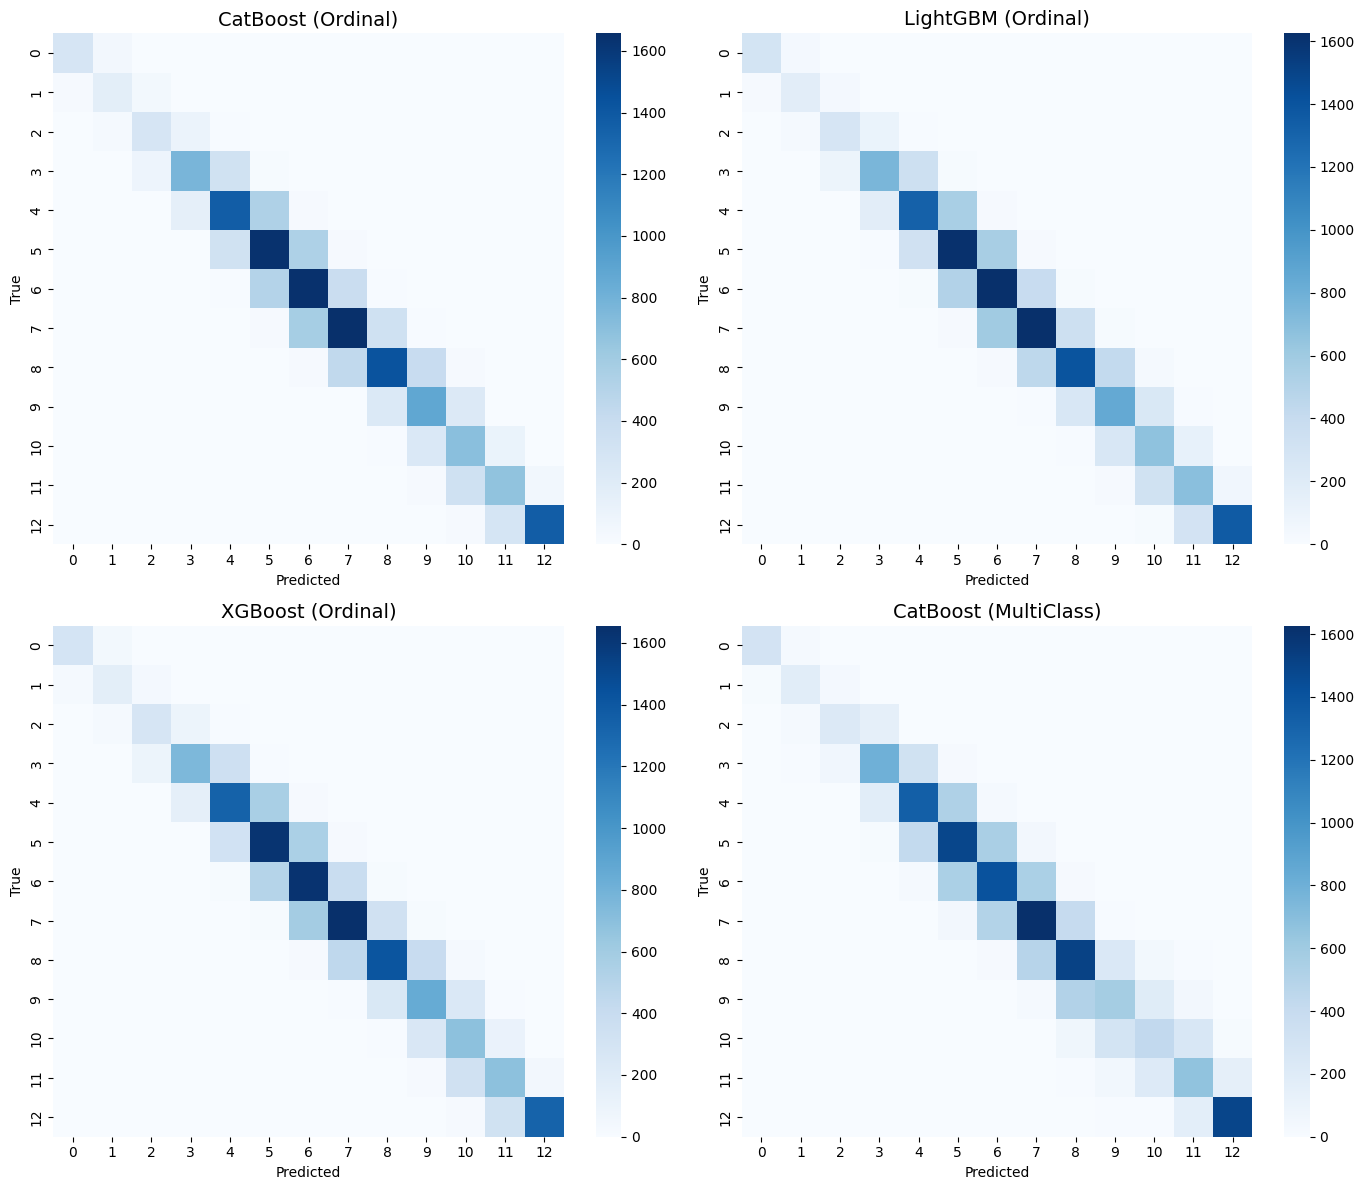

In [ ]:
model_preds = {
    "CatBoost (Ordinal)": y_pred_cat,
    "LightGBM (Ordinal)": y_pred_lgb,
    "XGBoost (Ordinal)":  y_pred_xgb,
    "CatBoost (MultiClass)": y_pred_cat_multi
}

fig, axes = plt.subplots(2, 2, figsize=(14, 12))
axes = axes.flatten()

for ax, (name, preds) in zip(axes, model_preds.items()):
    cm = confusion_matrix(y_tree_test, preds)
    sns.heatmap(cm, cmap="Blues", annot=False, ax=ax)
    ax.set_title(name, fontsize=14)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")

plt.tight_layout()
plt.show()

# FEATURE SELECTION (Top-K Search)

In [ ]:
importances = final_cat.get_feature_importance()
feat_names = X_train_red.columns

df_imp = pd.DataFrame({
    "feature": feat_names,
    "importance": importances
}).sort_values("importance", ascending=False)

df_imp

,feature,importance
8,HSMainSystemEfficiency,33.750654
0,UValueWall,16.459465
2,UValueFloor,9.522368
1,UValueRoof,5.463394
15,GroundFloorArea(sq m),5.426539
3,UValueWindow,2.931988
10,HSEffAdjFactor,2.913998
23,FirstFloorArea,2.693581
16,WallArea,2.686252
12,DistributionLosses,2.319480


In [ ]:
def evaluate_top_k(k):
    topk_feats = df_imp.head(k)["feature"].tolist()
    cat_topk = [c for c in cat_features_red if c in topk_feats]

    model = CatBoostRegressor(**best_cat_params_fixed)

    model.fit(
        X_train_red[topk_feats],
        y_tree_train,
        cat_features=cat_topk,
        eval_set=(X_test_red[topk_feats], y_tree_test),
        verbose=False
    )

    # Predict → round → ordinal
    y_pred_cont = model.predict(X_test_red[topk_feats])
    y_pred = np.round(y_pred_cont).clip(0, y_tree_train.max()).astype(int)

    qwk = cohen_kappa_score(y_tree_test, y_pred, weights="quadratic")
    acc = accuracy_score(y_tree_test, y_pred)

    return qwk, acc

In [ ]:
results = []

feature_count = len(df_imp)

# Test K = all features down to 10
for k in range(feature_count, 9, -1):
    qwk, acc = evaluate_top_k(k)

    results.append({
        "K": k,
        "QWK": qwk,
        "Accuracy": acc,
        "Δ QWK vs Full": qwk - baseline_qwk,
        "Δ Accuracy vs Full": acc - baseline_acc
    })

results_df = pd.DataFrame(results)
results_df

,K,QWK,Accuracy,Δ QWK vs Full,Δ Accuracy vs Full
0,40,0.976430,0.661894,0.000587,0.007288
1,39,0.976455,0.660765,0.000611,0.006159
2,38,0.976571,0.661227,0.000727,0.006620
3,37,0.976375,0.659225,0.000531,0.004619
4,36,0.976206,0.656864,0.000362,0.002258
5,35,0.976309,0.659122,0.000465,0.004516
6,34,0.976123,0.656967,0.000279,0.002361
7,33,0.976059,0.655633,0.000215,0.001026
8,32,0.976202,0.656094,0.000359,0.001488
9,31,0.975795,0.652502,-0.000049,-0.002104


In [ ]:
best_row = results_df.loc[results_df["QWK"].idxmax()]
best_row

,2
K,38.000000
QWK,0.976571
Accuracy,0.661227
Δ QWK vs Full,0.000727
Δ Accuracy vs Full,0.006620


In [ ]:
best_k = int(best_row["K"])
final_features = df_imp.head(best_k)["feature"].tolist()

print("FINAL SELECTED FEATURES:")
for f in final_features:
    print("-", f)


FINAL SELECTED FEATURES:
- HSMainSystemEfficiency
- UValueWall
- UValueFloor
- UValueRoof
- GroundFloorArea(sq m)
- UValueWindow
- HSEffAdjFactor
- FirstFloorArea
- WallArea
- DistributionLosses
- PermeabilityTest
- InsulationThickness
- NoOfChimneys
- WaterStorageVolume
- InsulationType
- RoofArea
- ElecImmersionInSummer
- FloorArea
- FirstFloorHeight
- WindowArea
- ManuLossFactorAvail
- GroundFloorHeight
- DoorArea
- ThermalMassCategory
- NoOfFansAndVents
- NoOfSidesSheltered
- UvalueDoor
- PredominantRoofTypeArea
- HSSupplHeatFraction
- GroundFloorArea
- SolarHotWaterHeating
- NoOfOpenFlues
- PercentageDraughtStripped
- PredominantRoofType
- SuspendedWoodenFloor
- DraftLobby
- TGDLEdition
- VentilationMethod


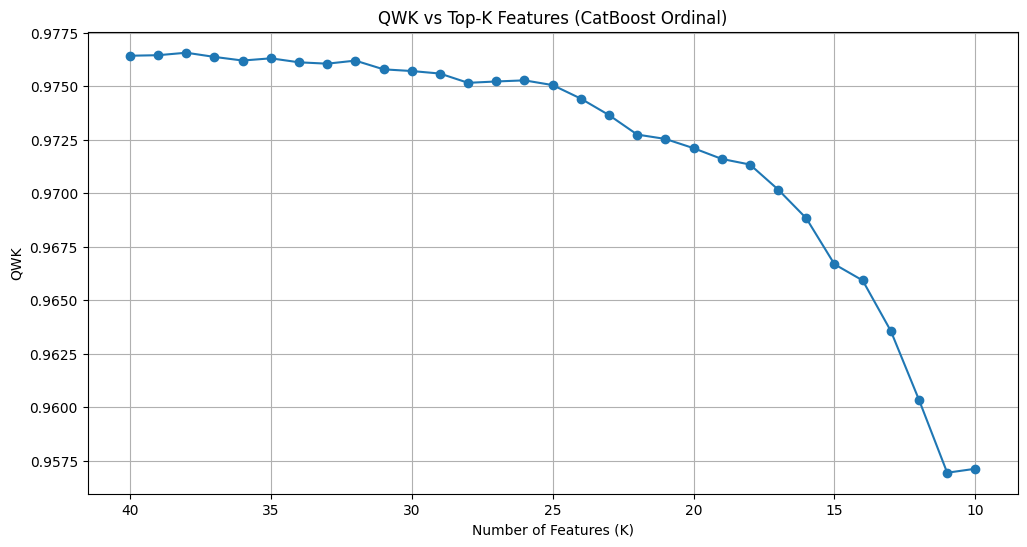

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
plt.plot(results_df["K"], results_df["QWK"], marker="o")
plt.xlabel("Number of Features (K)")
plt.ylabel("QWK")
plt.title("QWK vs Top-K Features (CatBoost Ordinal)")
plt.gca().invert_xaxis()
plt.grid(True)
plt.show()


# FINAL EVALUATION OF MODELS AFTER TUNING AND FEATURE SELECTION

In [ ]:
final_features = df_imp.head(best_k)["feature"].tolist()
cat_final = [c for c in cat_features_red if c in final_features]

final_cat_k = CatBoostRegressor(**best_cat_params_fixed)

final_cat_k.fit(
    X_train_red[final_features],
    y_tree_train,
    cat_features=cat_final,
    eval_set=(X_test_red[final_features], y_tree_test),
    verbose=False
)

# Predictions with best-K model
y_pred_k_cont = final_cat_k.predict(X_test_red[final_features])
y_pred_k = np.round(y_pred_k_cont).clip(0, y_tree_train.max()).astype(int)


In [ ]:
final_lgbm = lgb.LGBMRegressor(**best_lgbm_params_fixed)

final_lgbm.fit(
    X_train_red[final_features],
    y_tree_train,
    eval_set=[(X_test_red[final_features], y_tree_test)],
    callbacks=[
        lgb.early_stopping(stopping_rounds=100),
        lgb.log_evaluation(period=0)
    ]
)

# Predict and round to ordinal classes
y_pred_lgb_cont = final_lgbm.predict(X_test_red[final_features])
y_pred_lgb = np.round(y_pred_lgb_cont).clip(0, y_tree_train.max()).astype(int)


Training until validation scores don't improve for 100 rounds
Did not meet early stopping. Best iteration is:
[2373]	valid_0's rmse: 0.576394


In [ ]:
from xgboost import XGBRegressor

final_xgb = XGBRegressor(**best_xgb_params_fixed, enable_categorical=True)

final_xgb.fit(
    X_train_red[final_features],
    y_tree_train,
    eval_set=[(X_test_red[final_features], y_tree_test)],
    verbose=False
)

# Predict and round
y_pred_xgb_cont = final_xgb.predict(X_test_red[final_features])
y_pred_xgb = np.round(y_pred_xgb_cont).clip(0, y_tree_train.max()).astype(int)


In [ ]:
# Filter categorical features for final CatBoost Multiclass
cat_final_multi = [c for c in cat_features_red if c in final_features]

final_cat_multi = CatBoostClassifier(
    **best_cat_multi_params_fixed,

)

final_cat_multi.fit(
    X_train_red[final_features],
    y_tree_train,
    cat_features=cat_final_multi,
    eval_set=(X_test_red[final_features], y_tree_test),
    verbose=False
)

# Predict and convert to integers
y_pred_multi = final_cat_multi.predict(X_test_red[final_features]).astype(int)


In [ ]:
final_qwk_catord = cohen_kappa_score(y_tree_test, y_pred_k, weights="quadratic")
final_acc_catord = accuracy_score(y_tree_test, y_pred_k)

final_qwk_lgb = cohen_kappa_score(y_tree_test, y_pred_lgb, weights="quadratic")
final_acc_lgb = accuracy_score(y_tree_test, y_pred_lgb)

final_qwk_xgb = cohen_kappa_score(y_tree_test, y_pred_xgb, weights="quadratic")
final_acc_xgb = accuracy_score(y_tree_test, y_pred_xgb)

final_qwk_multi = cohen_kappa_score(y_tree_test, y_pred_multi, weights="quadratic")
final_acc_multi = accuracy_score(y_tree_test, y_pred_multi)

In [ ]:
final_results = pd.DataFrame({
    "Model": ["CatBoost Ordinal", "LightGBM", "XGBoost", "CatBoost Multiclass"],
    "QWK": [final_qwk_catord, final_qwk_lgb, final_qwk_xgb, final_qwk_multi],
    "Accuracy": [final_acc_catord, final_acc_lgb, final_acc_xgb, final_acc_multi]
})

final_results


,Model,QWK,Accuracy
0,CatBoost Ordinal,0.976571,0.661227
1,LightGBM,0.975251,0.647011
2,XGBoost,0.974888,0.651065
3,CatBoost Multiclass,0.967940,0.618527


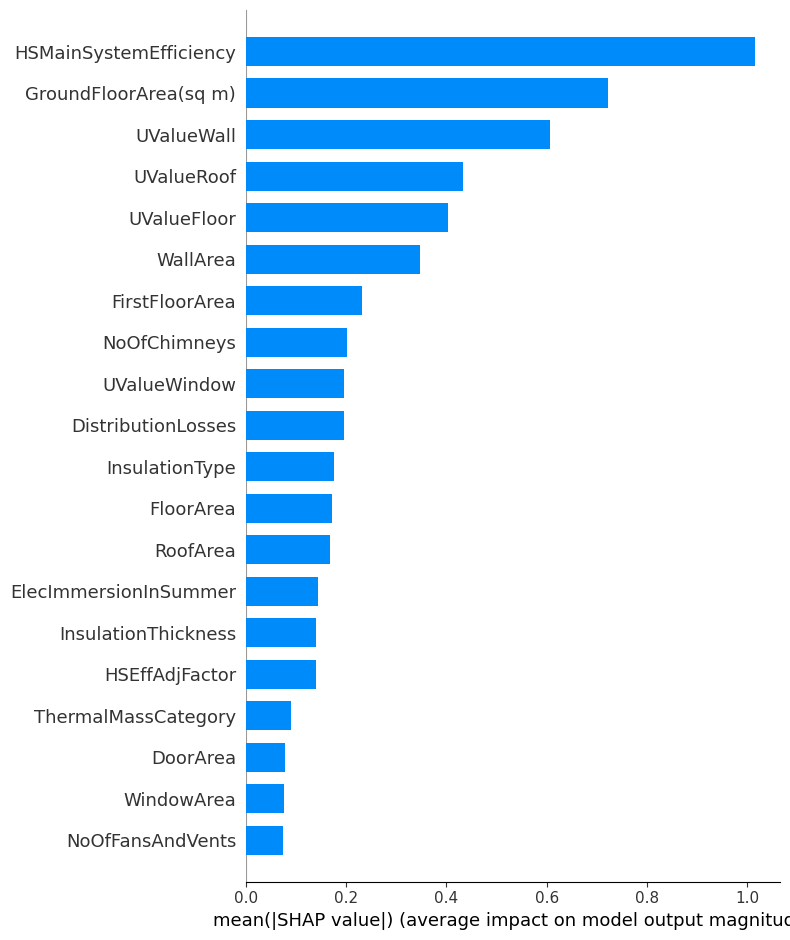

In [ ]:
import shap
shap.initjs()

explainer = shap.TreeExplainer(final_cat_k)
shap_values = explainer.shap_values(X_test_red[final_features])

# Bar Plot (global importance)
shap.summary_plot(shap_values, X_test_red[final_features], plot_type="bar")



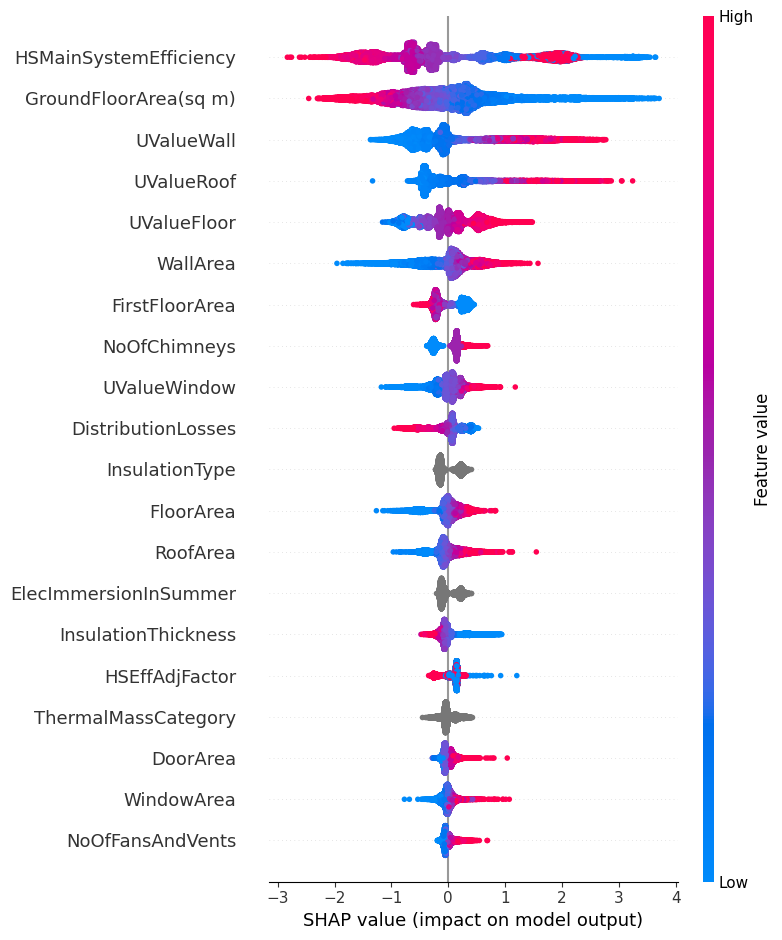

In [ ]:

# Beeswarm Plot (detailed)
shap.summary_plot(shap_values, X_test_red[final_features])

In [ ]:
baseline_data = {
    "Model": [
        "CatBoost Ordinal (Baseline)",
        "LightGBM Ordinal (Baseline)",
        "XGBoost Ordinal (Baseline)",
        "CatBoost Multiclass (Baseline)"
    ],
    "QWK": [0.9545, 0.9679, 0.9644, 0.9480],
    "Accuracy": [0.4552, 0.5781, 0.5618, 0.4987]
}


df_baseline = pd.DataFrame(baseline_data)
df_tuned = pd.DataFrame(final_results)
df_combined = pd.concat([df_baseline, final_results], axis=0)
df_combined


,Model,QWK,Accuracy
0,CatBoost Ordinal (Baseline),0.954500,0.455200
1,LightGBM Ordinal (Baseline),0.967900,0.578100
2,XGBoost Ordinal (Baseline),0.964400,0.561800
3,CatBoost Multiclass (Baseline),0.948000,0.498700
0,CatBoost Ordinal,0.976571,0.661227
1,LightGBM,0.975251,0.647011
2,XGBoost,0.974888,0.651065
3,CatBoost Multiclass,0.967940,0.618527


/tmp/ipython-input-2582275848.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


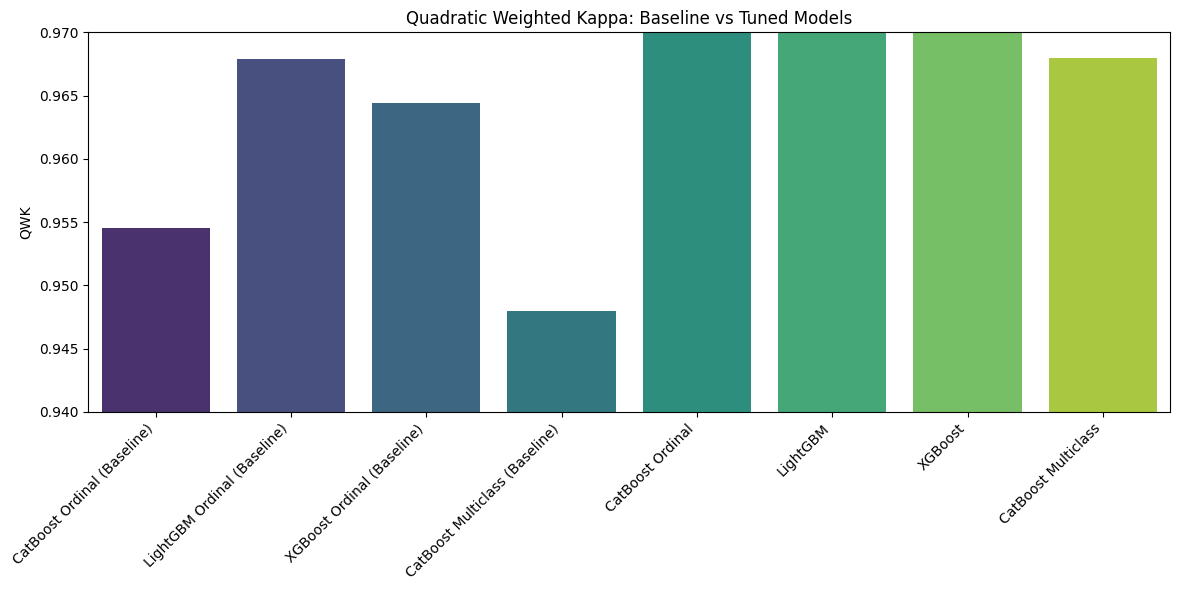

In [ ]:
plt.figure(figsize=(12,6))
sns.barplot(
    data=df_combined,
    x="Model",
    y="QWK",
    palette="viridis"
)
plt.xticks(rotation=45, ha="right")
plt.ylim(0.94, 0.97)
plt.title("Quadratic Weighted Kappa: Baseline vs Tuned Models")
plt.ylabel("QWK")
plt.xlabel("")
plt.tight_layout()
plt.show()

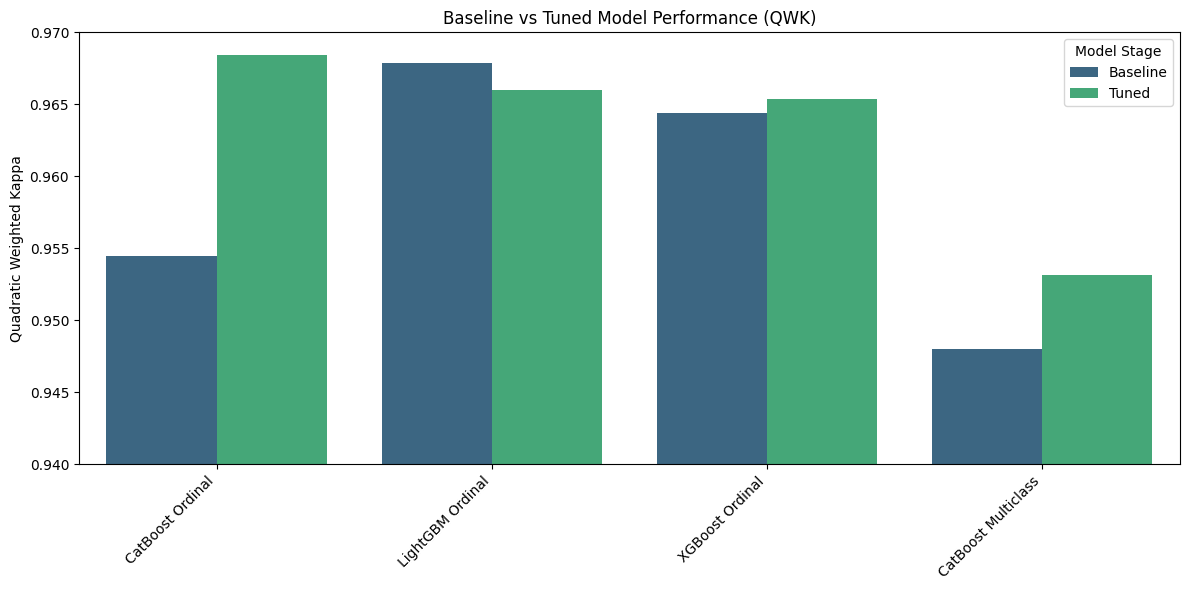

In [ ]:
# Build a tidy DataFrame for grouped plotting
df_compare = pd.DataFrame({
    "Model": [
        "CatBoost Ordinal", "CatBoost Ordinal",
        "LightGBM Ordinal", "LightGBM Ordinal",
        "XGBoost Ordinal", "XGBoost Ordinal",
        "CatBoost Multiclass", "CatBoost Multiclass"
    ],
    "Stage": [
        "Baseline", "Tuned",
        "Baseline", "Tuned",
        "Baseline", "Tuned",
        "Baseline", "Tuned"
    ],
    "QWK": [
        0.9545, 0.968456,
        0.9679, 0.965972,
        0.9644, 0.965393,
        0.9480, 0.953180
    ]
})

plt.figure(figsize=(12, 6))

sns.barplot(
    data=df_compare,
    x="Model",
    y="QWK",
    hue="Stage",
    palette="viridis"
)

plt.ylim(0.94, 0.97)  # <-- Zoomed Y-axis to highlight differences
plt.title("Baseline vs Tuned Model Performance (QWK)")
plt.ylabel("Quadratic Weighted Kappa")
plt.xlabel("")
plt.xticks(rotation=45, ha="right")

plt.legend(title="Model Stage")
plt.tight_layout()
plt.show()
